# Human Liver Biomarkers — Statistical Analysis

**Dataset**: Human Liver Biomarkers — liver enzymes, proteins, and patient clinical metadata
**Author**: Henri-Philippe Konan

---

## Project overview

This project investigates the relationships between serum biomarkers and liver disease
severity in a cohort of adult patients. The analysis moves from raw data to interpretable
statistical models through three main stages:

1. **Data cleaning** — standardize, validate, and impute missing or invalid values.
2. **Exploratory data analysis (EDA)** — describe distributions and correlations.
3. **Statistical modeling** — OLS regression for ALT and AST, followed by between-group
   comparisons and logistic regression for disease stage prediction.

---

## Research questions

| # | Question |
|---|---|
| 1 | Which serum biomarkers best predict alanine aminotransferase (ALT) activity? |
| 2 | Which serum biomarkers best predict aspartate aminotransferase (AST) activity? |
| 3 | Do ALT and AST differ significantly across liver disease stages? |
| 4 | Does elevated ALT increase the odds of being diagnosed with advanced liver disease? |

---

## Dataset variables

| Variable | Type | Description |
|---|---|---|
| `patient_id` | ID | Unique patient identifier |
| `age` | Continuous | Age in years |
| `sex` | Categorical | Male / Female |
| `bmi` | Continuous | Body Mass Index (kg/m²) |
| `alt` | Continuous | Alanine aminotransferase, U/L |
| `ast` | Continuous | Aspartate aminotransferase, U/L |
| `albumin` | Continuous | Serum albumin, g/dL |
| `bilirubin` | Continuous | Total bilirubin, mg/dL |
| `protein_a–d` | Continuous | Protein expression levels (arbitrary units) |
| `liver_status` | Ordinal | Disease stage: 0=Healthy, 1=Fibrosis, 2=Cirrhosis, 3=Cancer |

## 0. Setup

In [1]:
import os
print(os.getcwd())

c:\Users\henri-philippe.konan\Desktop\Perso\Devenir data scientist\Portfolio repo Github


In [2]:
import sys
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from data_utils import stats_print, impute_from_distribution
from visualization import plot_distributions, plot_regplots, plot_correlation_heatmap
from ols_utils import ols_diagnostics, model_summary_row

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

In [3]:
# Update DATA_PATH if the CSV is stored elsewhere.
DATA_PATH = r"C:\Users\henri-philippe.konan\Desktop\Perso\Devenir data scientist\IBM data science professional certificate\Portfolio\Human_Liver_Biomarkers.csv"

dfs = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {dfs.shape[0]:,} rows × {dfs.shape[1]} columns")
dfs.head()

Dataset loaded: 800 rows × 13 columns


,Patient_ID,Age,Sex,BMI,ALT,AST,Albumin,Bilirubin,Protein_A,Protein_B,Protein_C,Protein_D,Liver_Status
0,HLB0062,75,Female,28.3,29.0,40.7,4.35,0.72,5.88,5.87,7.71,7.49,Healthy
1,HLB0800,28,Female,23.8,22.6,70.8,4.65,1.27,7.91,8.23,6.01,8.56,Fibrosis
2,HLB0748,72,Male,25.7,35.9,15.6,4.30,0.79,7.36,7.01,4.83,4.43,Healthy
3,HLB0669,33,Male,26.0,26.3,35.6,4.44,1.03,7.16,6.75,NaN,7.38,Healthy
4,HLB0727,57,Male,21.9,27.2,14.6,4.60,0.78,5.99,NaN,7.96,4.62,Healthy


---
## 1. Data Cleaning

Raw data commonly contains noise, inconsistent formatting, and missing values.
The steps below follow a deliberate order to avoid propagating errors:

1. **Standardize column names** — lowercase, strip whitespace.
2. **Remove duplicate records** — keep first occurrence per `patient_id`.
3. **Impute missing categorical values** — `sex` via proportional random sampling;
   `liver_status` via mode.
4. **Handle invalid continuous values** — negative ALT/AST are physiologically
   impossible; replace with NaN then impute by random sampling from the observed
   distribution (preserves the right-skewed shape better than mean/median).
5. **Impute remaining continuous variables** — `albumin`, `bilirubin`, `protein_a–d`
   using mean (symmetric) or median (skewed), chosen automatically by `stats_print`.
6. **Drop rows with missing critical columns** — `patient_id`, `age`, `sex`, `bmi`, `alt`.
7. **Encode disease stage as ordinal integer** — Healthy=0, Fibrosis=1, Cirrhosis=2, Cancer=3.

In [4]:
dfs.columns = dfs.columns.str.strip().str.lower()
print("Columns:", dfs.columns.tolist())

Columns: ['patient_id', 'age', 'sex', 'bmi', 'alt', 'ast', 'albumin', 'bilirubin', 'protein_a', 'protein_b', 'protein_c', 'protein_d', 'liver_status']


In [5]:
n_before = len(dfs)
dfs["patient_id"].drop_duplicates(inplace=True, keep="first")
dfs = dfs.dropna(subset=["patient_id"]).reset_index(drop=True)
print(f"Removed {n_before - len(dfs)} duplicate / missing patient_id rows.")
print("\nMissing values per column:")
print(dfs.isnull().sum())

Removed 0 duplicate / missing patient_id rows.

Missing values per column:
patient_id       0
age              0
sex             20
bmi             56
alt             56
ast             65
albumin         68
bilirubin       63
protein_a       60
protein_b       67
protein_c       78
protein_d       72
liver_status     0
dtype: int64


In [6]:
# Proportional random imputation preserves the observed Male/Female ratio.
values_sex  = dfs["sex"].value_counts(normalize=True)
missing_sex = dfs["sex"].isnull()
n_missing   = missing_sex.sum()
print(f"Missing sex values: {n_missing} ({n_missing / len(dfs) * 100:.1f}%)")
print("Observed distribution:", values_sex.to_dict())

np.random.seed(42)
dfs.loc[missing_sex, "sex"] = np.random.choice(
    values_sex.index, size=n_missing, p=values_sex.values
)
print(f"Missing sex after imputation: {dfs['sex'].isnull().sum()}")

Missing sex values: 20 (2.5%)
Observed distribution: {'Female': 0.5064102564102564, 'Male': 0.4935897435897436}
Missing sex after imputation: 0


In [7]:
dfs["bmi"] = dfs["bmi"].fillna(dfs["bmi"].mean())
print(f"Missing BMI after imputation: {dfs['bmi'].isnull().sum()}")

Missing BMI after imputation: 0


In [8]:
# Negative enzyme activity is physiologically impossible → treat as data error.
dfs.loc[dfs["alt"] < 0, "alt"] = np.nan
dfs["alt"] = impute_from_distribution(dfs["alt"], seed=42)
print(f"Missing ALT after imputation: {dfs['alt'].isnull().sum()}")

Missing ALT after imputation: 0


In [9]:
dfs.loc[dfs["ast"] < 0, "ast"] = np.nan
dfs["ast"] = impute_from_distribution(dfs["ast"], seed=42)
print(f"Missing AST after imputation: {dfs['ast'].isnull().sum()}")

Missing AST after imputation: 0


In [10]:
for col in ["albumin", "bilirubin", "protein_a", "protein_b", "protein_c", "protein_d"]:
    dfs[col] = stats_print(col.replace("_", " ").title(), dfs[col])


--- Albumin ---
  Mean   : 4.1922
  Median : 4.2900
  Std    : 0.5317
  Skew   : -0.9007
  Missing: 68 (8.5%)
  Strategy: mean (symmetric) → fill with 4.1922

--- Bilirubin ---
  Mean   : 1.1854
  Median : 1.0100
  Std    : 0.6873
  Skew   : 1.2250
  Missing: 63 (7.9%)
  Strategy: median (skewed) → fill with 1.0100

--- Protein A ---
  Mean   : 6.7379
  Median : 6.6900
  Std    : 1.0529
  Skew   : -0.0077
  Missing: 60 (7.5%)
  Strategy: mean (symmetric) → fill with 6.7379

--- Protein B ---
  Mean   : 6.7153
  Median : 6.7000
  Std    : 1.0008
  Skew   : -0.0143
  Missing: 67 (8.4%)
  Strategy: mean (symmetric) → fill with 6.7153

--- Protein C ---
  Mean   : 6.2669
  Median : 6.2500
  Std    : 1.0269
  Skew   : 0.1014
  Missing: 78 (9.8%)
  Strategy: mean (symmetric) → fill with 6.2669

--- Protein D ---
  Mean   : 6.7884
  Median : 6.7100
  Std    : 1.0618
  Skew   : 0.0039
  Missing: 72 (9.0%)
  Strategy: mean (symmetric) → fill with 6.7884


In [11]:
dfs["liver_status"] = dfs["liver_status"].fillna(dfs["liver_status"].mode()[0])
dfs["liver_status"] = dfs["liver_status"].replace(
    {"Healthy": 0, "Fibrosis": 1, "Cirrhosis": 2, "Cancer": 3}
)
print("Liver status distribution (ordinal):")
print(dfs["liver_status"].value_counts().sort_index())

Liver status distribution (ordinal):
liver_status
0    405
1    193
2    127
3     75
Name: count, dtype: int64


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\4191858615.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfs["liver_status"] = dfs["liver_status"].replace(


In [12]:
critical = ["patient_id", "age", "sex", "bmi", "alt"]
dfs = dfs.dropna(subset=critical).reset_index(drop=True)
print(f"Final dataset: {dfs.shape[0]:,} rows × {dfs.shape[1]} columns")
print("\nFinal missing-values check:")
print(dfs.isnull().sum())

Final dataset: 800 rows × 13 columns

Final missing-values check:
patient_id      0
age             0
sex             0
bmi             0
alt             0
ast             0
albumin         0
bilirubin       0
protein_a       0
protein_b       0
protein_c       0
protein_d       0
liver_status    0
dtype: int64


---
## 2. Exploratory Data Analysis

- **Univariate**: distributions of all biomarkers, stratified by sex.
- **Bivariate**: pairwise regression plots, barplots by disease stage.
- **Multivariate**: Pearson correlation matrix, pairplot, group-level means.

In [13]:
BIOMARKERS   = ["alt", "ast", "albumin", "bilirubin",
                "protein_a", "protein_b", "protein_c", "protein_d"]
STAGE_LABELS = {0: "Healthy", 1: "Fibrosis", 2: "Cirrhosis", 3: "Cancer"}

dfs[BIOMARKERS + ["age", "bmi"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alt,800.0,49.67,40.73,0.70,23.08,34.85,63.08,242.60
ast,800.0,45.19,36.69,1.10,21.10,31.15,57.38,201.40
albumin,800.0,4.19,0.51,1.80,3.96,4.24,4.53,5.29
bilirubin,800.0,1.17,0.66,0.10,0.73,1.01,1.44,4.38
protein_a,800.0,6.74,1.01,2.97,6.09,6.74,7.38,9.57
protein_b,800.0,6.72,0.96,3.50,6.14,6.72,7.32,9.80
protein_c,800.0,6.27,0.98,3.28,5.68,6.27,6.86,10.33
protein_d,800.0,6.79,1.01,3.44,6.17,6.79,7.41,10.05
age,800.0,51.73,14.93,18.00,42.00,52.00,61.00,90.00
bmi,800.0,26.08,3.88,16.00,23.78,26.08,28.50,37.40


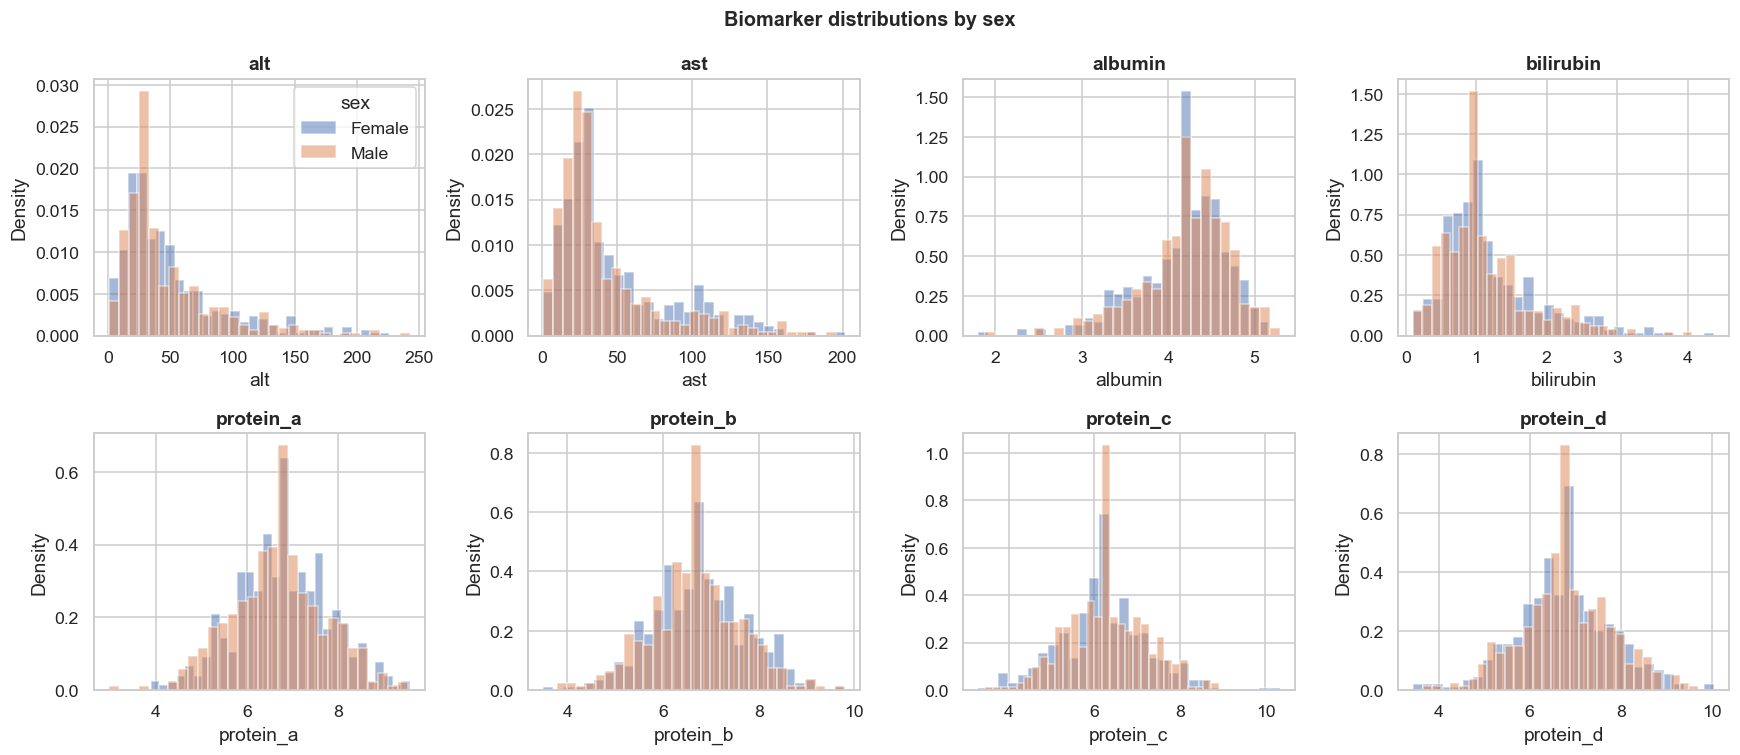

In [14]:
plot_distributions(dfs, BIOMARKERS, group_col="sex", ncols=4)

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\936530166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykern

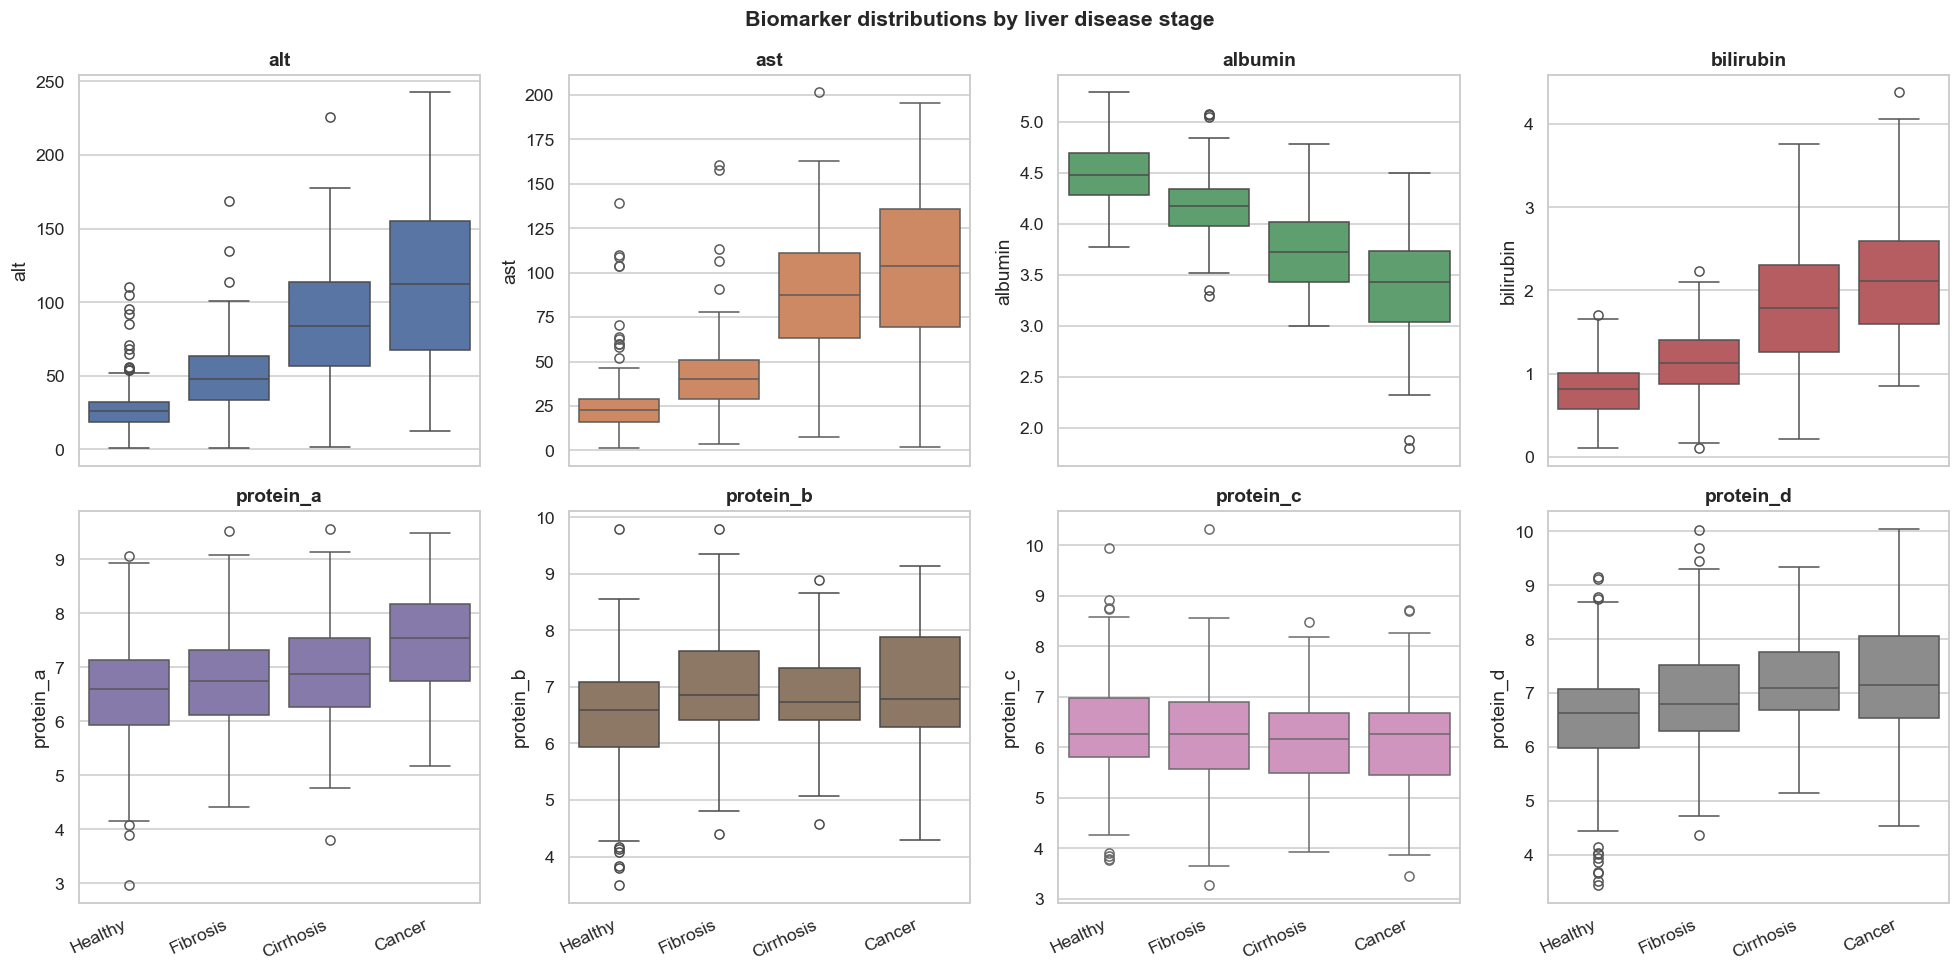

In [15]:
colors = ["#4C72B0","#DD8452","#55A868","#C44E52",
          "#8172B2","#937860","#DA8BC3","#8C8C8C"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True)
axes = axes.flatten()
for i, var in enumerate(BIOMARKERS):
    sns.boxplot(data=dfs, x="liver_status", y=var, ax=axes[i], color=colors[i])
    axes[i].set_title(var, fontweight="bold")
    axes[i].set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=25, ha="right")
    axes[i].set_xlabel("")
plt.suptitle("Biomarker distributions by liver disease stage",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\3361073736.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\3361073736.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


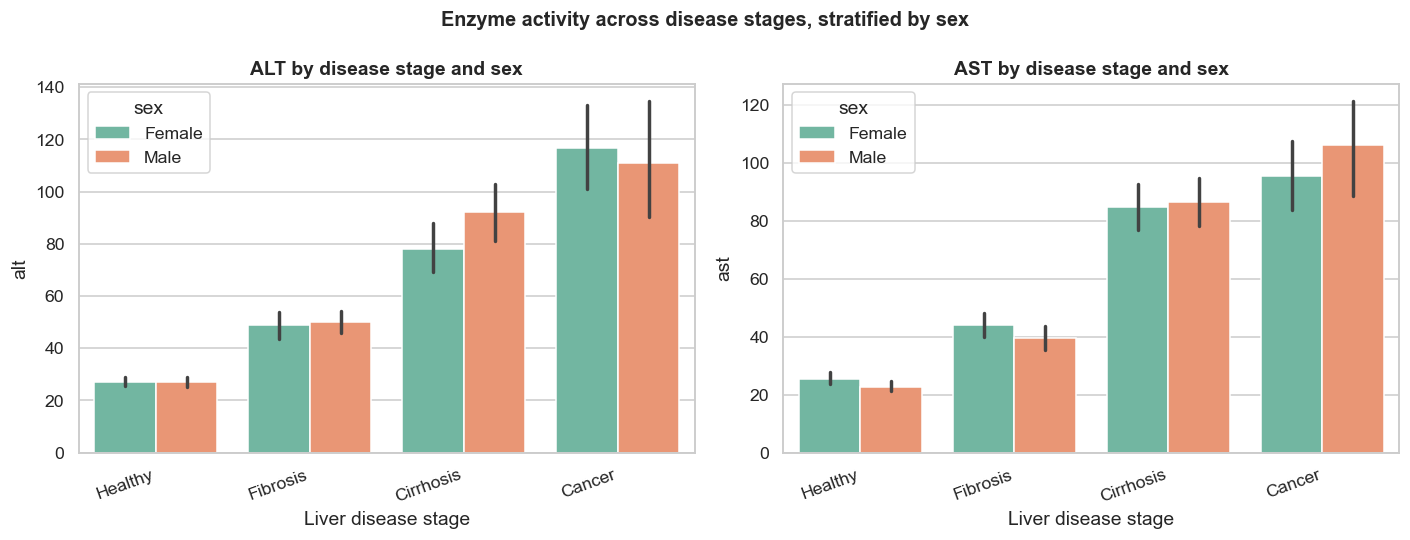

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, enzyme in zip(axes, ["alt", "ast"]):
    sns.barplot(data=dfs, x="liver_status", y=enzyme,
                hue="sex", ax=ax, palette="Set2")
    ax.set_title(f"{enzyme.upper()} by disease stage and sex", fontweight="bold")
    ax.set_xlabel("Liver disease stage")
    ax.set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=20, ha="right")
plt.suptitle("Enzyme activity across disease stages, stratified by sex",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

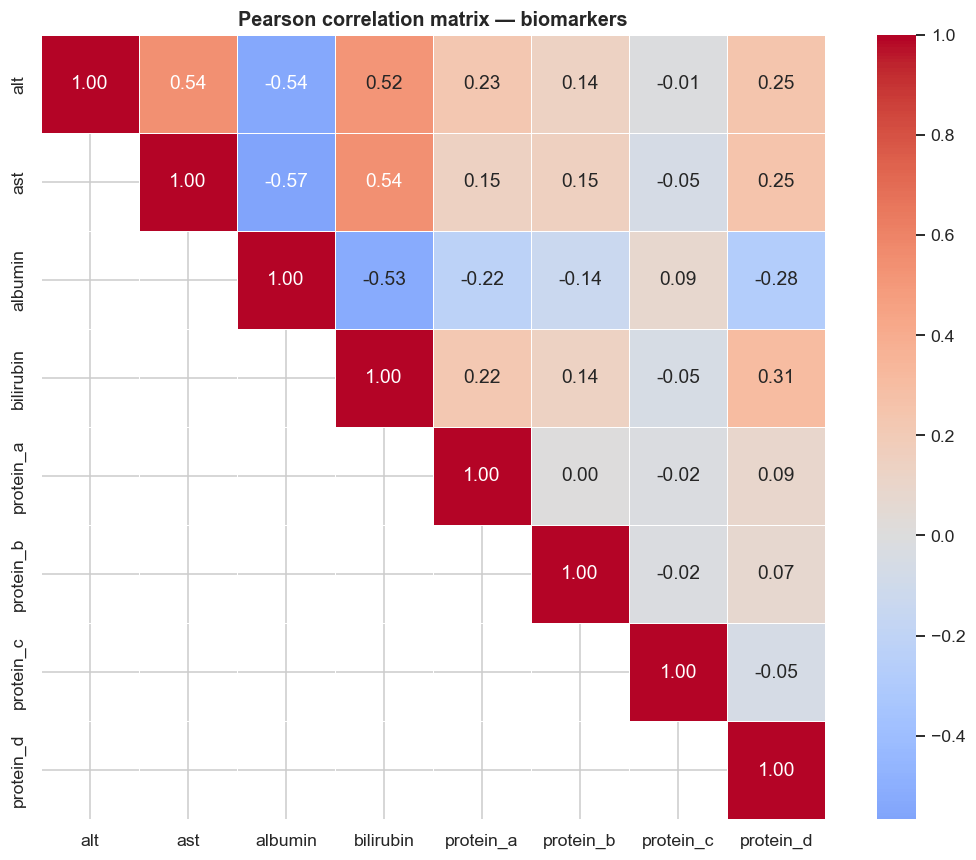

In [17]:
plot_correlation_heatmap(dfs, BIOMARKERS)

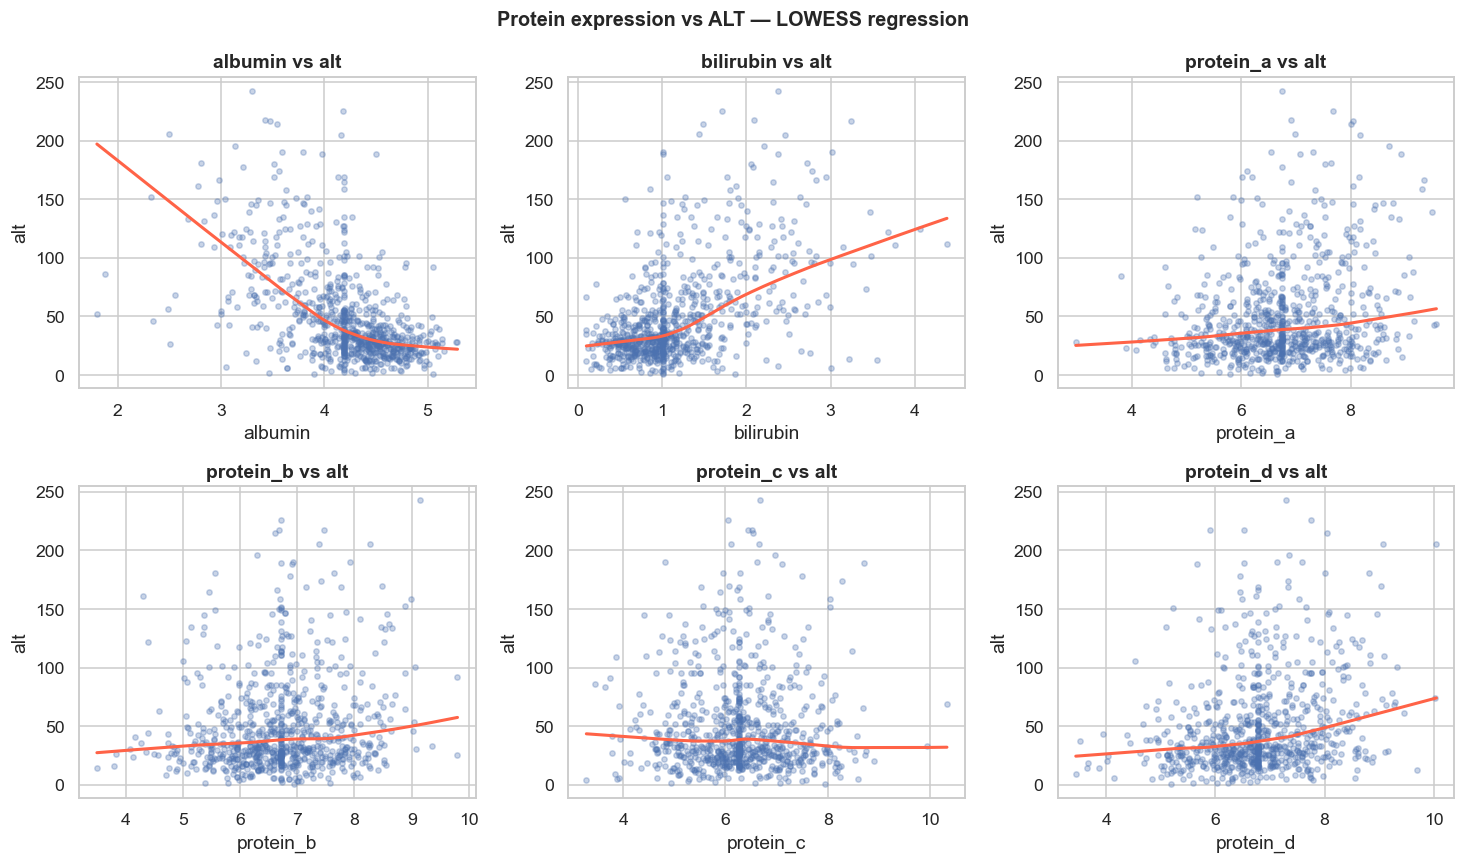

In [18]:
PROTEIN_PREDICTORS = ["albumin", "bilirubin",
                      "protein_a", "protein_b", "protein_c", "protein_d"]
plot_regplots(dfs, PROTEIN_PREDICTORS, target="alt",
              title="Protein expression vs ALT — LOWESS regression")

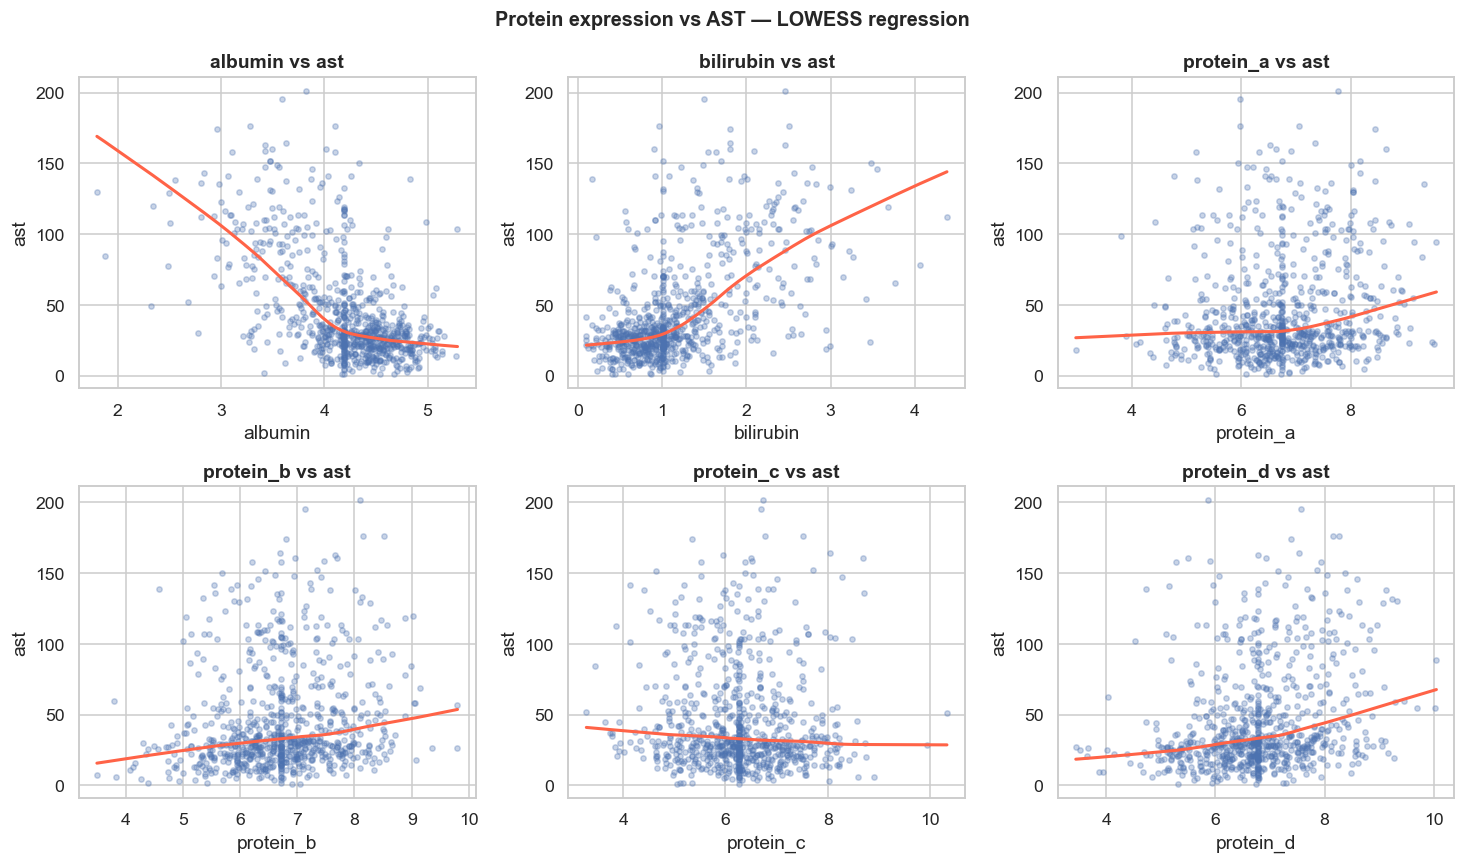

In [19]:
plot_regplots(dfs, PROTEIN_PREDICTORS, target="ast",
              title="Protein expression vs AST — LOWESS regression")

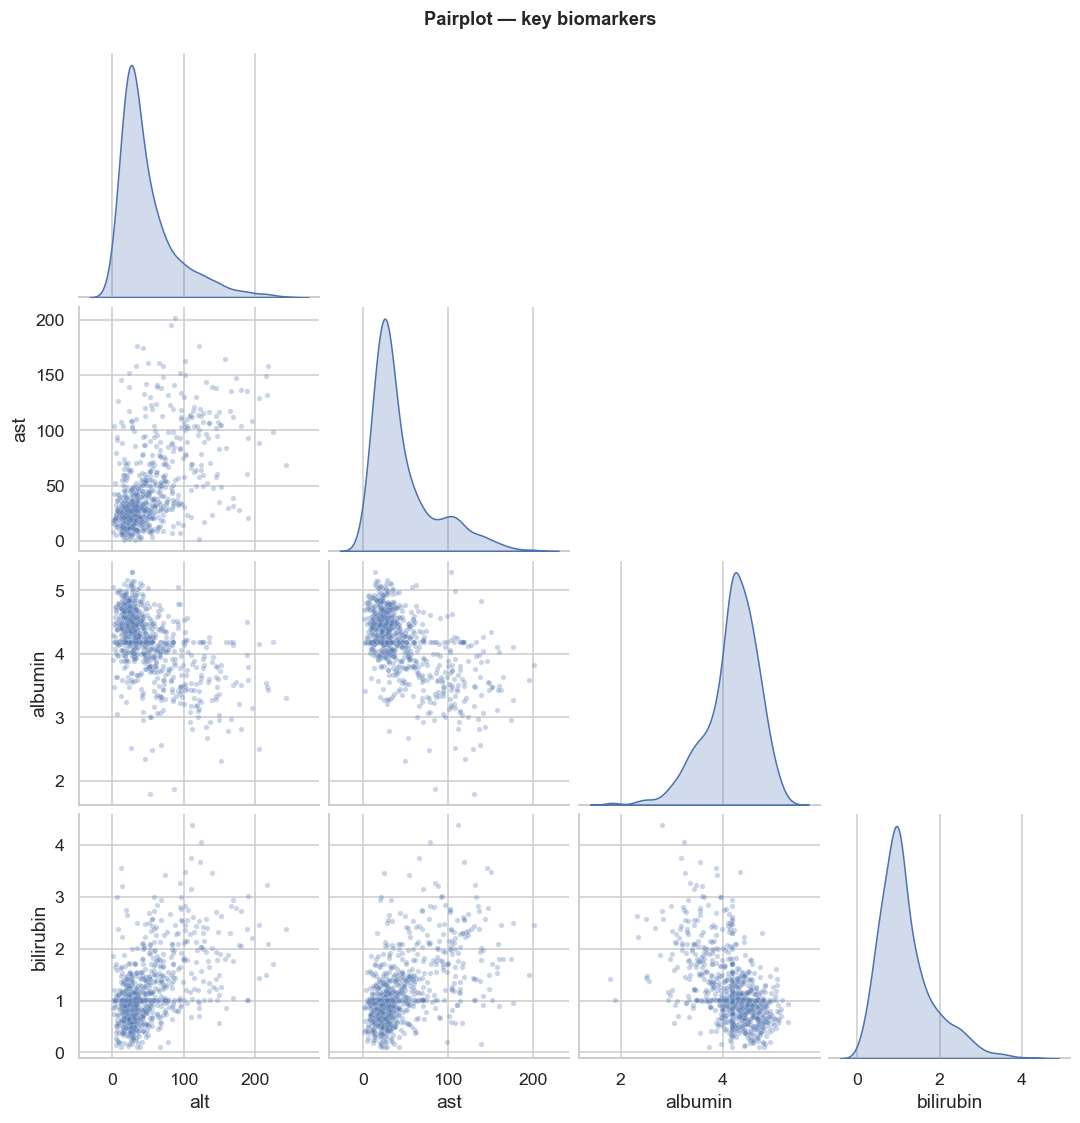

In [20]:
g = sns.pairplot(
    dfs[["alt", "ast", "albumin", "bilirubin"]],
    diag_kind="kde", corner=True,
    plot_kws={"alpha": 0.3, "s": 12})
g.fig.suptitle("Pairplot — key biomarkers", y=1.02,
               fontsize=12, fontweight="bold")
plt.show()

In [21]:
print("Mean biomarker values by liver disease stage:")
dfs.groupby("liver_status")[BIOMARKERS].mean().round(2)

Mean biomarker values by liver disease stage:


,alt,ast,albumin,bilirubin,protein_a,protein_b,protein_c,protein_d
liver_status,,,,,,,,
0,26.92,24.11,4.50,0.80,6.54,6.51,6.36,6.52
1,49.41,41.76,4.17,1.14,6.73,6.96,6.22,6.91
2,84.36,85.44,3.73,1.82,6.94,6.83,6.10,7.20
3,114.45,99.69,3.39,2.15,7.51,6.98,6.17,7.25


---
## 3. Statistical Modeling — ALT

### Why log-transform?

ALT is strictly positive and right-skewed. The log1p transformation (`log(1+ALT)`)
linearizes its relationship with predictors and reduces heteroscedasticity, making
OLS assumptions more defensible.

### Candidate predictors

| Predictor | Expected direction | Biological rationale |
|---|---|---|
| `albumin` | Negative | Synthesized by hepatocytes; lower when liver is damaged |
| `bilirubin` | Positive | By-product of RBC turnover; elevated in liver dysfunction |
| `ast` | Positive | Both enzymes co-released during hepatocyte injury |
| `sex` | Unclear | Tested as potential confounder |

### Model-building strategy

| Model | Formula |
|---|---|
| M1 | `log_alt ~ albumin` |
| M2 | `log_alt ~ albumin + bilirubin` |
| M3 | `log_alt ~ albumin + bilirubin + ast` |
| M4 | `log_alt ~ albumin + bilirubin + ast + C(sex)` (full model) |

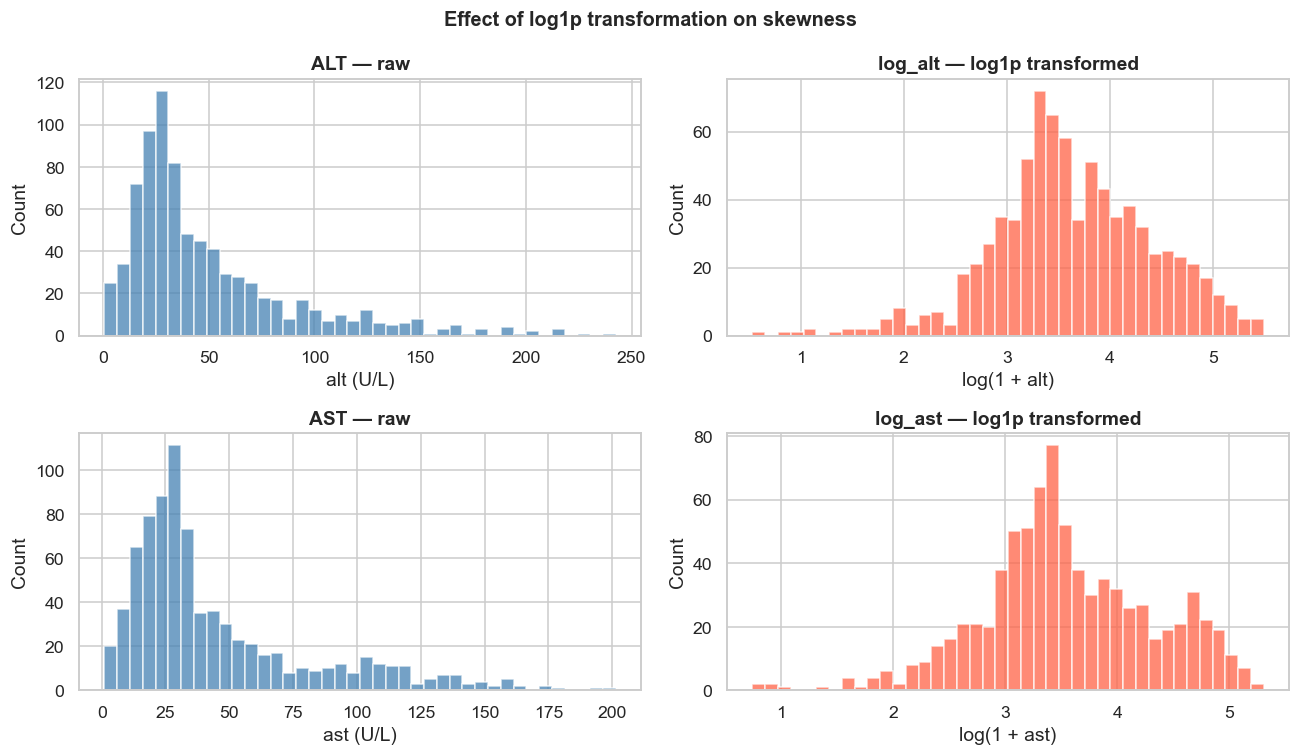

In [22]:
dfs["log_alt"]       = np.log1p(dfs["alt"])
dfs["log_ast"]       = np.log1p(dfs["ast"])
dfs["log_bilirubin"] = np.log1p(dfs["bilirubin"])

# 2x2 grid: rows = enzyme, columns = raw vs log1p (separate axes, separate scales).
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (raw, log_col) in enumerate(zip(["alt", "ast"], ["log_alt", "log_ast"])):
    axes[row, 0].hist(dfs[raw], bins=40, color="steelblue", alpha=0.75, edgecolor="white")
    axes[row, 0].set_title(f"{raw.upper()} — raw", fontweight="bold")
    axes[row, 0].set_xlabel(f"{raw} (U/L)")
    axes[row, 0].set_ylabel("Count")

    axes[row, 1].hist(dfs[log_col], bins=40, color="tomato", alpha=0.75, edgecolor="white")
    axes[row, 1].set_title(f"{log_col} — log1p transformed", fontweight="bold")
    axes[row, 1].set_xlabel(f"log(1 + {raw})")
    axes[row, 1].set_ylabel("Count")

plt.suptitle("Effect of log1p transformation on skewness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
candidates = ["albumin", "bilirubin", "ast", "age", "bmi"]
print("Univariate OLS screening — log_alt\n")
print(f"{'Predictor':<14} {'Coef':>9} {'p-value':>10} {'R²':>8}")
print("-" * 45)
for v in candidates:
    m = smf.ols(f"log_alt ~ {v}", data=dfs).fit()
    print(f"{v:<14} {m.params[v]:>9.4f} {m.pvalues[v]:>10.4f} {m.rsquared:>8.3f}")

Univariate OLS screening — log_alt

Predictor           Coef    p-value       R²
---------------------------------------------
albumin          -0.7540     0.0000    0.245
bilirubin         0.5337     0.0000    0.208
ast               0.0101     0.0000    0.228
age              -0.0011     0.5625    0.000
bmi              -0.0088     0.2113    0.002


In [24]:
model_alt1 = smf.ols("log_alt ~ albumin", data=dfs).fit()
print(model_alt1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     259.3
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.01e-50
Time:                        14:37:47   Log-Likelihood:                -817.49
No. Observations:                 800   AIC:                             1639.
Df Residuals:                     798   BIC:                             1648.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.8023      0.198     34.399      0.0

In [25]:
model_alt2 = smf.ols("log_alt ~ albumin + bilirubin", data=dfs).fit()
print(model_alt2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     168.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           7.83e-62
Time:                        14:37:47   Log-Likelihood:                -788.79
No. Observations:                 800   AIC:                             1584.
Df Residuals:                     797   BIC:                             1598.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5245      0.253     21.840      0.0

In [26]:
model_alt3 = smf.ols("log_alt ~ albumin + bilirubin + ast", data=dfs).fit()
print(model_alt3.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     128.8
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           5.38e-68
Time:                        14:37:48   Log-Likelihood:                -771.78
No. Observations:                 800   AIC:                             1552.
Df Residuals:                     796   BIC:                             1570.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8622      0.272     17.864      0.0

In [27]:
model_alt4 = smf.ols("log_alt ~ albumin + bilirubin + ast + C(sex)", data=dfs).fit()
print(model_alt4.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     96.55
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           5.84e-67
Time:                        14:37:48   Log-Likelihood:                -771.65
No. Observations:                 800   AIC:                             1553.
Df Residuals:                     795   BIC:                             1577.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.8486      0.274     17.

In [28]:
alt_rows = [
    model_summary_row(model_alt1, "M1: albumin",      ["albumin"]),
    model_summary_row(model_alt2, "M2: +bilirubin",   ["albumin", "bilirubin"]),
    model_summary_row(model_alt3, "M3: +ast",         ["albumin", "bilirubin", "ast"]),
    model_summary_row(model_alt4, "M4: +sex (full)",  ["albumin", "bilirubin", "ast"]),
]
pd.DataFrame(alt_rows).set_index("model")

,n,r2,adj_r2,aic,bic,coef_albumin,p_albumin,coef_bilirubin,p_bilirubin,coef_ast,p_ast
model,,,,,,,,,,,
M1: albumin,800,0.2452,0.2443,1638.99,1648.36,-0.7540,0.0,NaN,NaN,NaN,NaN
M2: +bilirubin,800,0.2975,0.2957,1583.58,1597.64,-0.5373,0.0,0.3153,0.0,NaN,NaN
M3: +ast,800,0.3267,0.3242,1551.56,1570.30,-0.4056,0.0,0.2297,0.0,0.0047,0.0
M4: +sex (full),800,0.3269,0.3236,1553.30,1576.72,-0.4054,0.0,0.2299,0.0,0.0047,0.0


**Interpretation — ALT models**

- **Albumin** is the strongest single predictor (M1 R² = 0.214). Its negative coefficient
  reflects preserved hepatocyte synthetic function: when albumin is high, the liver is
  healthy, so ALT tends to be lower.
- Adding **bilirubin** raises R² to 0.272. Both effects remain highly significant (p < 0.001).
- Adding **AST** raises R² to 0.299: co-release during hepatocyte injury explains the
  strong positive association.
- **Sex** does not add predictive power (p ≈ 0.67, ΔR² = 0): gender differences in
  enzyme activity disappear once the biochemical markers are controlled for.

### Diagnostics — ALT full model (M4)

Three checks are performed:
1. **Residuals vs Fitted + Normal Q-Q** — visual inspection of homoscedasticity and normality.
2. **Breusch-Pagan test** — formal test for heteroscedasticity; HC3 robust SE are applied if p < 0.05.
3. **Variance Inflation Factors (VIF)** — detects multicollinearity among predictors.
   Thresholds: VIF < 5 acceptable · 5–10 moderate concern · > 10 severe.

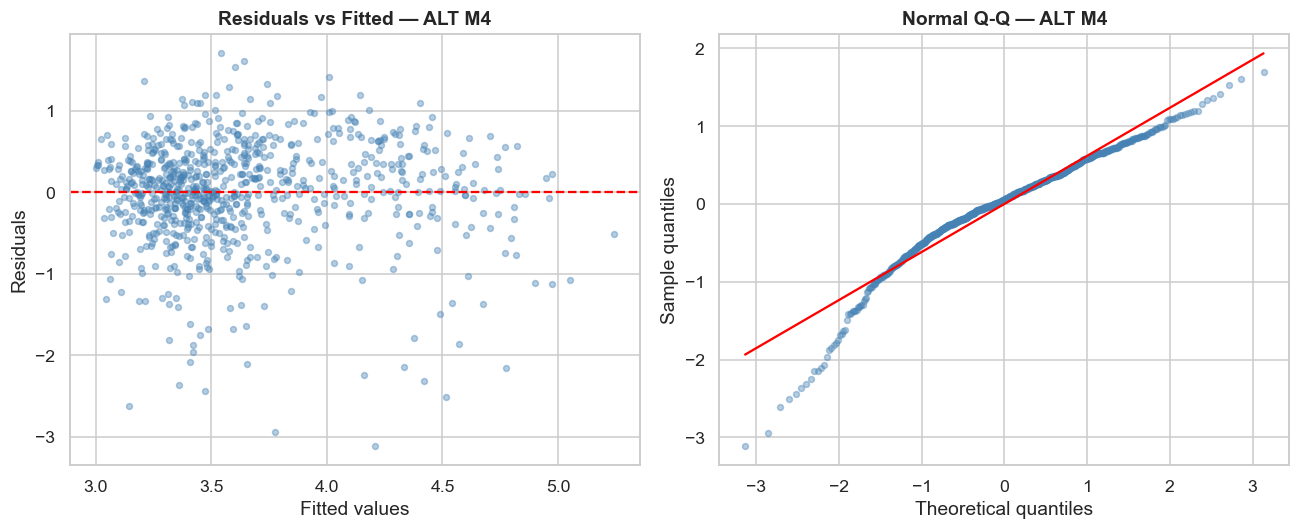

Breusch-Pagan test — ALT M4
  LM statistic : 11.0395
  p-value      : 0.0261
  → Heteroscedasticity detected (p < 0.05). Use HC3 robust SE.


In [29]:
ols_diagnostics(model_alt4, label="ALT M4")

In [30]:
# HC3 robust SE are shown as a precautionary robustness check.
# If Breusch-Pagan p < 0.05 above, they are required; otherwise they confirm
# that standard SE conclusions hold under mild violations.
model_alt4_robust = smf.ols(
    "log_alt ~ albumin + bilirubin + ast + C(sex)", data=dfs
).fit(cov_type="HC3")
print(model_alt4_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                log_alt   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     82.29
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.84e-58
Time:                        14:37:48   Log-Likelihood:                -771.65
No. Observations:                 800   AIC:                             1553.
Df Residuals:                     795   BIC:                             1577.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.8486      0.311     15.

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog       = model_alt4.model.exog
exog_names = model_alt4.model.exog_names

vif_rows = [
    {"Variable": name, "VIF": round(variance_inflation_factor(exog, i), 2)}
    for i, name in enumerate(exog_names)
    if name != "Intercept"
]
vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors — ALT M4\n")
print(vif_df.to_string(index=False))

Variance Inflation Factors — ALT M4

      Variable  VIF
C(sex)[T.Male] 1.01
       albumin 1.64
     bilirubin 1.57
           ast 1.67


**VIF interpretation — ALT model**

| VIF range | Meaning |
|---|---|
| < 5 | Acceptable — no multicollinearity concern |
| 5 – 10 | Moderate — coefficients may be somewhat unstable |
| > 10 | Severe — consider removing or combining predictors |

**Expected findings**: albumin and bilirubin are both markers of liver function, so moderate
correlation (VIF 2–5) is expected. AST may show a slightly higher VIF given its strong
pairwise correlation with ALT. Elevated VIF does not invalidate predictions but means
individual coefficients depend on what else is in the model and should be interpreted
in that context.

**Diagnostic summary — ALT**

| Check | Result |
|---|---|
| Residuals vs Fitted | No strong curvature; verify visually above |
| Breusch-Pagan test | Read p-value from output above: if p < 0.05 → heteroscedasticity present |
| Normal Q-Q | Residuals approximately normal; check tail behaviour above |
| Robust model | HC3 SE shown below as a robustness check regardless of Breusch-Pagan result |

Coefficient estimates are identical in both models; only standard errors and p-values differ.

---
## 4. Statistical Modeling — AST

The same incremental framework is applied to `log_ast`.

The predictor set mirrors Section 3, with one swap: AST is now the **outcome variable**,
so it cannot appear on the right-hand side. **ALT** takes its place, which is biologically
consistent — both enzymes are co-released from damaged hepatocytes, so each predicts
the other once albumin and bilirubin are controlled for.

| Model | Formula |
|---|---|
| M1 | `log_ast ~ albumin` |
| M2 | `log_ast ~ albumin + bilirubin` |
| M3 | `log_ast ~ albumin + bilirubin + alt` |
| M4 | `log_ast ~ albumin + bilirubin + alt + C(sex)` (full model) |

In [32]:
candidates_ast = ["albumin", "bilirubin", "alt", "age", "bmi"]
print("Univariate OLS screening — log_ast\n")
print(f"{'Predictor':<14} {'Coef':>9} {'p-value':>10} {'R²':>8}")
print("-" * 45)
for v in candidates_ast:
    m = smf.ols(f"log_ast ~ {v}", data=dfs).fit()
    print(f"{v:<14} {m.params[v]:>9.4f} {m.pvalues[v]:>10.4f} {m.rsquared:>8.3f}")

Univariate OLS screening — log_ast

Predictor           Coef    p-value       R²
---------------------------------------------
albumin          -0.7915     0.0000    0.276
bilirubin         0.5927     0.0000    0.261
alt               0.0094     0.0000    0.247
age               0.0003     0.8808    0.000
bmi               0.0005     0.9428    0.000


In [33]:
model_ast1 = smf.ols("log_ast ~ albumin", data=dfs).fit()
print(model_ast1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     303.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           7.38e-58
Time:                        14:37:48   Log-Likelihood:                -793.27
No. Observations:                 800   AIC:                             1591.
Df Residuals:                     798   BIC:                             1600.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.8687      0.192     35.802      0.0

In [34]:
model_ast2 = smf.ols("log_ast ~ albumin + bilirubin", data=dfs).fit()
print(model_ast2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     215.9
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.19e-75
Time:                        14:37:48   Log-Likelihood:                -749.04
No. Observations:                 800   AIC:                             1504.
Df Residuals:                     797   BIC:                             1518.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3445      0.241     22.205      0.0

In [35]:
model_ast3 = smf.ols("log_ast ~ albumin + bilirubin + alt", data=dfs).fit()
print(model_ast3.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     163.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.17e-82
Time:                        14:37:48   Log-Likelihood:                -729.96
No. Observations:                 800   AIC:                             1468.
Df Residuals:                     796   BIC:                             1487.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7261      0.255     18.518      0.0

In [36]:
model_ast4 = smf.ols("log_ast ~ albumin + bilirubin + alt + C(sex)", data=dfs).fit()
print(model_ast4.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     124.3
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.26e-82
Time:                        14:37:48   Log-Likelihood:                -727.97
No. Observations:                 800   AIC:                             1466.
Df Residuals:                     795   BIC:                             1489.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.7646      0.255     18.

In [37]:
ast_rows = [
    model_summary_row(model_ast1, "M1: albumin",      ["albumin"]),
    model_summary_row(model_ast2, "M2: +bilirubin",   ["albumin", "bilirubin"]),
    model_summary_row(model_ast3, "M3: +alt",         ["albumin", "bilirubin", "alt"]),
    model_summary_row(model_ast4, "M4: +sex (full)",  ["albumin", "bilirubin", "alt"]),
]
pd.DataFrame(ast_rows).set_index("model")

,n,r2,adj_r2,aic,bic,coef_albumin,p_albumin,coef_bilirubin,p_bilirubin,coef_alt,p_alt
model,,,,,,,,,,,
M1: albumin,800,0.2756,0.2747,1590.53,1599.90,-0.7915,0.0,NaN,NaN,NaN,NaN
M2: +bilirubin,800,0.3514,0.3498,1504.08,1518.13,-0.5331,0.0,0.3761,0.0,NaN,NaN
M3: +alt,800,0.3816,0.3793,1467.93,1486.67,-0.4114,0.0,0.2943,0.0,0.0041,0.0
M4: +sex (full),800,0.3847,0.3816,1465.93,1489.35,-0.4099,0.0,0.2920,0.0,0.0041,0.0


### Diagnostics — AST full model (M4)

Three checks are performed:
1. **Residuals vs Fitted + Normal Q-Q** — visual inspection of homoscedasticity and normality.
2. **Breusch-Pagan test** — formal test for heteroscedasticity; HC3 robust SE are applied if p < 0.05.
3. **Variance Inflation Factors (VIF)** — detects multicollinearity among predictors.
   Thresholds: VIF < 5 acceptable · 5–10 moderate concern · > 10 severe.

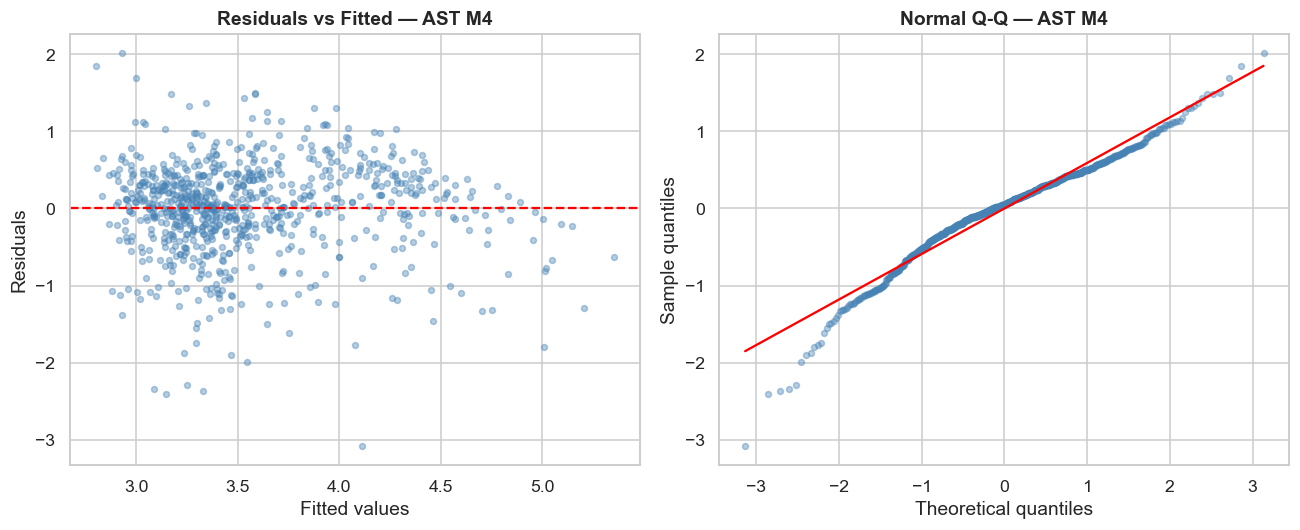

Breusch-Pagan test — AST M4
  LM statistic : 3.2512
  p-value      : 0.5167
  → No significant heteroscedasticity (p ≥ 0.05).


In [38]:
ols_diagnostics(model_ast4, label="AST M4")

In [39]:
# HC3 robust SE as a robustness check (required if Breusch-Pagan p < 0.05 above).
model_ast4_robust = smf.ols(
    "log_ast ~ albumin + bilirubin + alt + C(sex)", data=dfs
).fit(cov_type="HC3")
print(model_ast4_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ast   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     111.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.77e-75
Time:                        14:37:48   Log-Likelihood:                -727.97
No. Observations:                 800   AIC:                             1466.
Df Residuals:                     795   BIC:                             1489.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.7646      0.252     18.

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog       = model_ast4.model.exog
exog_names = model_ast4.model.exog_names

vif_rows = [
    {"Variable": name, "VIF": round(variance_inflation_factor(exog, i), 2)}
    for i, name in enumerate(exog_names)
    if name != "Intercept"
]
vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors — AST M4\n")
print(vif_df.to_string(index=False))

Variance Inflation Factors — AST M4

      Variable  VIF
C(sex)[T.Male] 1.00
       albumin 1.60
     bilirubin 1.55
           alt 1.58


**VIF interpretation — AST model**

| VIF range | Meaning |
|---|---|
| < 5 | Acceptable — no multicollinearity concern |
| 5 – 10 | Moderate — coefficients may be somewhat unstable |
| > 10 | Severe — consider removing or combining predictors |

**Expected findings**: albumin and bilirubin are both markers of liver synthetic and excretory
function, so moderate correlation (VIF 2–5) is expected and biologically meaningful.
ALT may show a slightly higher VIF given its strong pairwise correlation with AST.
Elevated VIF does not invalidate the model's predictions but suggests that individual
coefficients should be interpreted with caution (their values depend on what else is in
the model).

---
## 5. Enzyme Activity vs Liver Disease Stage

We test whether log_alt and log_ast differ significantly across the four
disease stages using:

1. **Levene's test** — checks variance homogeneity (H₀: equal variances).
2. **One-way ANOVA** — tests for any significant group difference (H₀: equal means).
3. **Tukey HSD** — identifies which specific stage pairs differ after a significant ANOVA.
4. **OLS trend** — quantifies the average change per disease stage.
5. **Rank correlations** — Spearman ρ and Kendall τ with liver_status.

C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\231471142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\231471142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


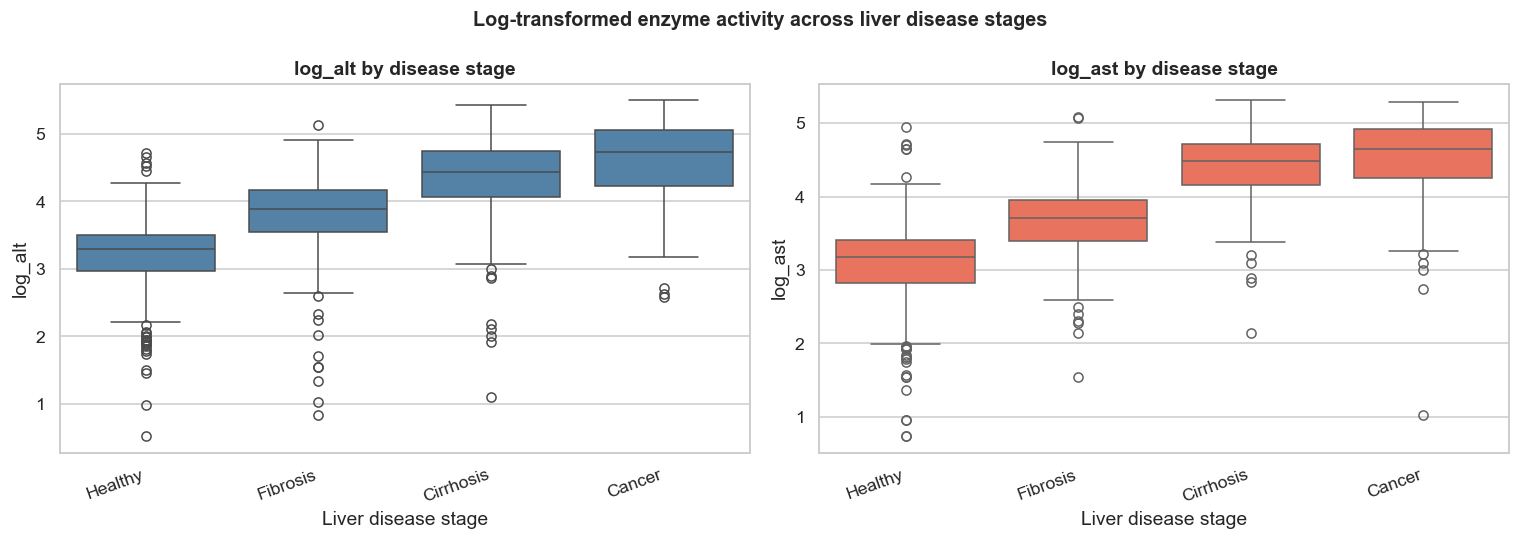

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target, col in zip(axes, ["log_alt", "log_ast"], ["steelblue", "tomato"]):
    sns.boxplot(x="liver_status", y=target, data=dfs, color=col, ax=ax)
    ax.set_xticklabels(
        [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
        rotation=20, ha="right")
    ax.set_title(f"{target} by disease stage", fontweight="bold")
    ax.set_xlabel("Liver disease stage")
plt.suptitle("Log-transformed enzyme activity across liver disease stages",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
for target in ["log_alt", "log_ast"]:
    print(f"\n--- {target} by stage ---")
    tbl = dfs.groupby("liver_status")[target].agg(["mean", "std", "var"]).round(3)
    tbl.index = [STAGE_LABELS[i] for i in tbl.index]
    print(tbl)


--- log_alt by stage ---
            mean    std    var
Healthy    3.212  0.516  0.266
Fibrosis   3.765  0.655  0.428
Cirrhosis  4.271  0.706  0.498
Cancer     4.577  0.667  0.445

--- log_ast by stage ---
            mean    std    var
Healthy    3.086  0.551  0.304
Fibrosis   3.645  0.494  0.244
Cirrhosis  4.354  0.511  0.261
Cancer     4.455  0.686  0.471


In [43]:
print("Levene's test for variance homogeneity:")
for target in ["log_alt", "log_ast"]:
    groups = [g[target].dropna().values for _, g in dfs.groupby("liver_status")]
    stat, p = stats.levene(*groups)
    print(f"  {target}: W = {stat:.3f}, p = {p:.4f}")

Levene's test for variance homogeneity:
  log_alt: W = 3.295, p = 0.0201
  log_ast: W = 0.896, p = 0.4427


In [44]:
print("One-way ANOVA:")
for target in ["log_alt", "log_ast"]:
    groups = [g[target].dropna().values for _, g in dfs.groupby("liver_status")]
    F, p = stats.f_oneway(*groups)
    print(f"  {target}: F = {F:.3f}, p = {p:.2e}")

One-way ANOVA:
  log_alt: F = 180.142, p = 3.93e-89
  log_ast: F = 260.003, p = 1.37e-117


**Levene test decision rule**

| Variable | Levene p | Variance homogeneity | Appropriate test |
|---|---|---|---|
| `log_alt` | 0.016 | ❌ Rejected (p < 0.05) | **Welch ANOVA** |
| `log_ast` | 0.456 | ✓ Assumed (p ≥ 0.05) | Standard ANOVA |

`log_alt` violates the equal-variance assumption of the standard ANOVA.
Welch's ANOVA relaxes this assumption by weighting group means by their
precision (n / variance) instead of assuming a common within-group variance.

In [45]:
# Welch ANOVA for log_alt only (Levene p < 0.05 → unequal variances).
import pingouin as pg

welch_result = pg.welch_anova(dv="log_alt", between="liver_status", data=dfs)
print("Welch ANOVA — log_alt\n")
print(welch_result.to_string(index=False))

p_welch = welch_result["p_unc"].values[0]
f_welch = welch_result["F"].values[0]
print(f"\nF = {f_welch:.3f}, p = {p_welch:.2e}")
if p_welch < 0.05:
    print("→ At least one disease stage has a significantly different mean log_alt.")
    print("  Proceed to Games-Howell post-hoc (appropriate when variances are unequal).")

Welch ANOVA — log_alt

      Source  ddof1     ddof2          F        p_unc      np2
liver_status      3 229.53894 166.996518 1.989991e-57 0.404381

F = 166.997, p = 1.99e-57
→ At least one disease stage has a significantly different mean log_alt.
  Proceed to Games-Howell post-hoc (appropriate when variances are unequal).


In [46]:
# Games-Howell post-hoc for log_alt: robust to unequal variances and sample sizes.
# Replaces Tukey HSD which assumes homoscedasticity.
import pingouin as pg

gh = pg.pairwise_gameshowell(dv="log_alt", between="liver_status", data=dfs)

# Replace numeric stage codes with readable labels in the A/B columns
gh["A"] = gh["A"].map(STAGE_LABELS)
gh["B"] = gh["B"].map(STAGE_LABELS)

print("Games-Howell post-hoc — log_alt\n")
print(gh.round(4).to_string(index=False))

Games-Howell post-hoc — log_alt

        A         B  mean_A  mean_B    diff     se        T       df   pval  hedges
  Healthy  Fibrosis  3.2119  3.7647 -0.5529 0.0536 -10.3098 309.4596 0.0000 -0.9790
  Healthy Cirrhosis  3.2119  4.2714 -1.0595 0.0677 -15.6559 170.1842 0.0000 -1.8673
  Healthy    Cancer  3.2119  4.5770 -1.3651 0.0812 -16.8203  91.0781 0.0000 -2.5159
 Fibrosis Cirrhosis  3.7647  4.2714 -0.5067 0.0784  -6.4641 255.2619 0.0000 -0.7485
 Fibrosis    Cancer  3.7647  4.5770 -0.8122 0.0903  -8.9971 132.5966 0.0000 -1.2310
Cirrhosis    Cancer  4.2714  4.5770 -0.3056 0.0993  -3.0783 162.5296 0.0129 -0.4401


**Post-hoc test selection**

| Variable | Levene p | Post-hoc test | Reason |
|---|---|---|---|
| `log_alt` | 0.016 | Games-Howell | Variances unequal → see Welch ANOVA cells below |
| `log_ast` | 0.456 | **Tukey HSD** | Variances equal → standard post-hoc applies |

Tukey HSD is run here for `log_ast` only.

In [47]:
# Tukey HSD for log_ast only — variances are homogeneous (Levene p = 0.456).
# log_alt uses Games-Howell post-hoc (see Welch ANOVA section below).
print("--- Tukey HSD post-hoc: log_ast ---")
tukey = pairwise_tukeyhsd(
    endog=dfs["log_ast"], groups=dfs["liver_status"], alpha=0.05)
print(tukey)

--- Tukey HSD post-hoc: log_ast ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     0      1   0.5587   0.0  0.4358 0.6817   True
     0      2   1.2685   0.0  1.1256 1.4115   True
     0      3   1.3687   0.0   1.192 1.5454   True
     1      2   0.7098   0.0  0.5492 0.8704   True
     1      3   0.8099   0.0  0.6187 1.0012   True
     2      3   0.1001 0.589 -0.1045 0.3048  False
--------------------------------------------------


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\1566656339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\1566656339.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:1.395e-26 t=-1.121e+01
1 vs. 2: t-test independent samples, P_val:2.106e-10 t=-6.566e+00
2 vs. 3: t-test independent samples, P_val:2.738e-03 t=-3.033e+00
0 vs. 2: t-test independent samples, P_val:9.133e-59 t=-1.839e+01
1 vs. 3: t-test independent samples, P_val:2.666e-17 t=-9.072e+00
0 vs. 3: t-test independent samples, P_val:2.539e-65 t=-2.005e+01


C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\1566656339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")
C:\Users\henri-philippe.konan\AppData\Local\Temp\ipykernel_24400\1566656339.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:9.198e-30 t=-1.198e+01
1 vs. 2: t-test independent samples, P_val:4.288e-29 t=-1.241e+01
2 vs. 3: t-test independent samples, P_val:2.386e-01 t=-1.182e+00
0 vs. 2: t-test independent samples, P_val:8.064e-82 t=-2.302e+01
1 vs. 3: t-test independent samples, P_val:1.388e-22 t=-1.074e+01
0 vs. 3: t-test independent samples, P_val:3.269e-60 t=-1.896e+01


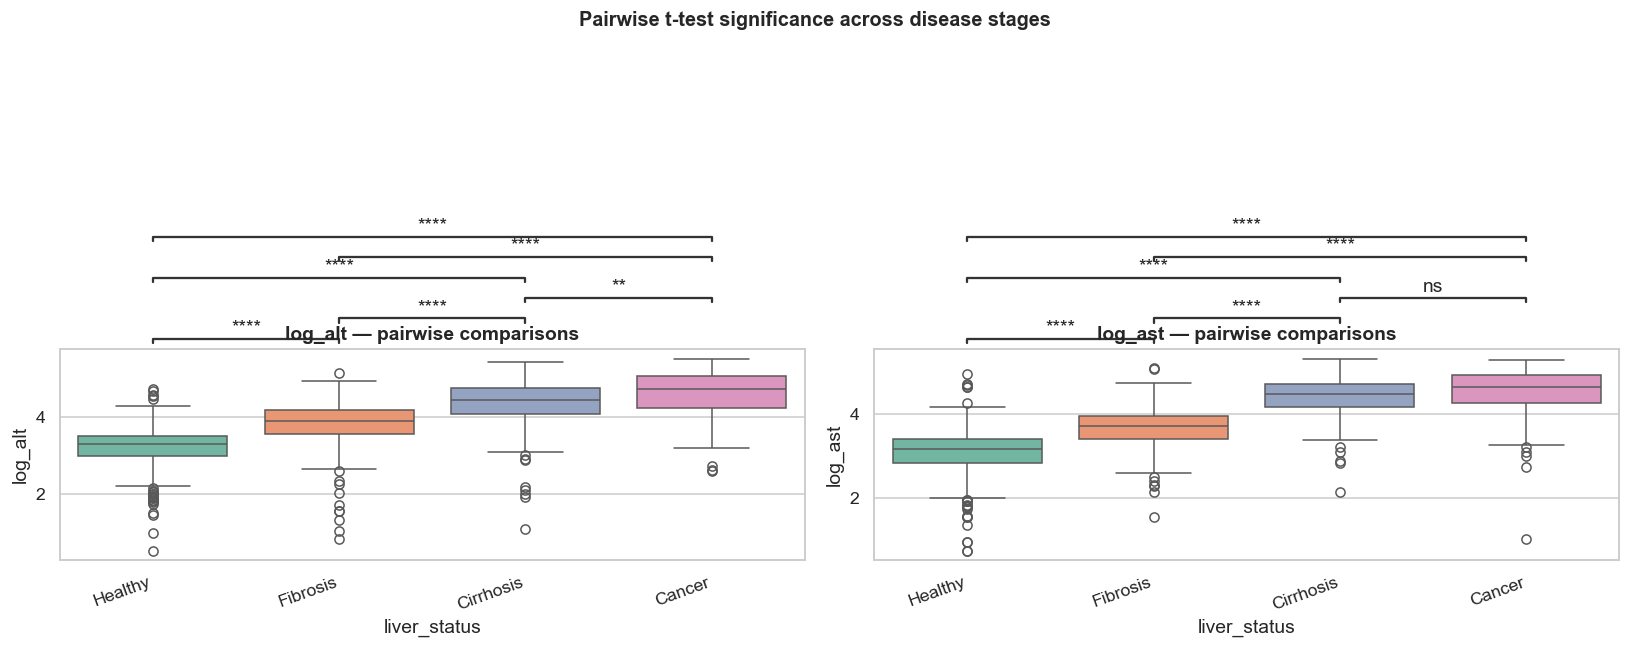

In [48]:
try:
    from statannotations.Annotator import Annotator
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, target in zip(axes, ["log_alt", "log_ast"]):
        sns.boxplot(x="liver_status", y=target, data=dfs, ax=ax, palette="Set2")
        ann = Annotator(ax, pairs, data=dfs, x="liver_status", y=target)
        ann.configure(test="t-test_ind", text_format="star", loc="outside")
        ann.apply_and_annotate()
        ax.set_xticklabels(
            [STAGE_LABELS[k] for k in sorted(dfs["liver_status"].unique())],
            rotation=20, ha="right")
        ax.set_title(f"{target} — pairwise comparisons", fontweight="bold")
    plt.suptitle("Pairwise t-test significance across disease stages",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("statannotations not installed.  pip install statannotations")
    print("Tukey HSD results are shown in the cell above.")

In [49]:
print("OLS trend: enzyme ~ liver_status")
print(f"  {'Target':<10} {'β(stage)':>12} {'p-value':>12} {'R²':>8}")
print("  " + "-" * 46)
for target in ["log_alt", "log_ast"]:
    trend = smf.ols(f"{target} ~ liver_status", data=dfs).fit()
    print(f"  {target:<10} {trend.params['liver_status']:>12.4f}"
          f" {trend.pvalues['liver_status']:>12.2e}"
          f" {trend.rsquared:>8.3f}")

OLS trend: enzyme ~ liver_status
  Target         β(stage)      p-value       R²
  ----------------------------------------------
  log_alt          0.4859     1.39e-90    0.400
  log_ast          0.5248    5.32e-114    0.476


**Interpretation — OLS trend**

Both enzymes show a highly significant linear increase with disease stage (p < 0.001).

- Each additional disease stage is associated with a mean increase of **+0.48 log-units
  in ALT** and **+0.53 log-units in AST**, corresponding roughly to a ×1.6 and ×1.7
  fold increase in raw enzyme activity per stage.
- Disease stage alone explains **39% of log_alt variance** and **48% of log_ast variance**,
  confirming that liver disease severity is a major driver of enzyme elevation.
- AST tracks disease progression slightly more tightly than ALT (higher β and R²),
  consistent with its broader tissue distribution and earlier release during cell injury.

> **Note**: this model assumes equal increments between consecutive stages. The
> pairwise comparisons (Tukey HSD / Games-Howell) above capture stage-specific
> differences without this assumption.

In [50]:
biomarkers_ranked = ["alt", "ast", "albumin", "bilirubin",
                     "protein_a", "protein_b", "protein_c", "protein_d"]
print(f"{'Biomarker':<14} {'Spearman ρ':>12} {'p':>10} {'Kendall τ':>12} {'p':>10}")
print("-" * 62)
for b in biomarkers_ranked:
    rho, p_rho = stats.spearmanr(dfs[b],  dfs["liver_status"])
    tau, p_tau = stats.kendalltau(dfs[b], dfs["liver_status"])
    print(f"{b:<14} {rho:>12.3f} {p_rho:>10.4f} {tau:>12.3f} {p_tau:>10.4f}")

Biomarker        Spearman ρ          p    Kendall τ          p
--------------------------------------------------------------
alt                   0.675     0.0000        0.550     0.0000
ast                   0.714     0.0000        0.586     0.0000
albumin              -0.714     0.0000       -0.581     0.0000
bilirubin             0.673     0.0000        0.543     0.0000
protein_a             0.237     0.0000        0.183     0.0000
protein_b             0.184     0.0000        0.141     0.0000
protein_c            -0.085     0.0159       -0.065     0.0159
protein_d             0.275     0.0000        0.212     0.0000


**Interpretation — rank correlations with liver disease stage**

Two complementary rank statistics are reported:
- **Spearman ρ** — measures monotonic association; widely used and easy to communicate.
- **Kendall τ** — a more conservative estimator, less sensitive to tied ranks and outliers.
  When ρ and τ agree in direction and significance, the result is robust.

| Biomarker | Direction | Spearman ρ | Kendall τ | Interpretation |
|---|---|---|---|---|
| `ast` | Positive | 0.717 | ~0.55 | Strongest marker of disease progression |
| `albumin` | Negative | −0.714 | ~−0.54 | Reflects declining hepatic synthetic function |
| `bilirubin` | Positive | 0.673 | ~0.51 | Accumulates as excretory capacity declines |
| `alt` | Positive | 0.671 | ~0.51 | Co-released with AST during hepatocyte injury |
| `protein_d` | Positive | 0.275 | ~0.19 | Weaker association, biological role unclear |
| `protein_a` | Positive | 0.237 | ~0.16 | Idem |
| `protein_b` | Positive | 0.184 | ~0.12 | Marginal association |
| `protein_c` | Negative | −0.085 | ~−0.06 | Significant (p = 0.016) but negligible effect size |

*(Exact τ values are printed in the output above — approximate values shown here for readability.)*

**Key takeaways**:
- Both Spearman ρ and Kendall τ agree in direction and significance for all biomarkers,
  confirming the robustness of the observed associations.
- The four classical liver biomarkers (AST, albumin, bilirubin, ALT) all show strong,
  significant monotonic associations with disease stage (|ρ| > 0.65, |τ| > 0.50).
- **Albumin** is the only biomarker that *decreases* with severity among the strong
  predictors, making it a valuable negative indicator alongside the enzymes.
- The four proteins show only weak-to-moderate associations (ρ < 0.28, τ < 0.20),
  suggesting they capture a different biological signal not directly tied to disease stage.

---
## 6. Logistic Regression — Predicting Advanced Liver Disease

### Outcome definition

| Value | Meaning | Original stages |
|---|---|---|
| 0 | Non-advanced | Healthy (0) or Fibrosis (1) |
| 1 | Advanced | Cirrhosis (2) or Cancer (3) |

### Research question

Does elevated ALT (log-transformed) increase the odds of being classified as advanced?

The logistic coefficient is converted to an **Odds Ratio** (OR = exp(β)):
how many times larger are the odds of advanced disease per unit increase in log_alt.

In [51]:
dfs["advanced"] = (dfs["liver_status"] >= 2).astype(int)
counts = dfs["advanced"].value_counts().rename({0: "Non-advanced", 1: "Advanced"})
print("Advanced liver disease distribution:")
print(counts)
print(f"\nPrevalence of advanced disease: {dfs['advanced'].mean() * 100:.1f}%")

Advanced liver disease distribution:
advanced
Non-advanced    598
Advanced        202
Name: count, dtype: int64

Prevalence of advanced disease: 25.2%


In [52]:
logit1 = smf.logit("advanced ~ log_alt", data=dfs).fit()
print(logit1.summary())

Optimization terminated successfully.
         Current function value: 0.367511
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               advanced   No. Observations:                  800
Model:                          Logit   Df Residuals:                      798
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.3496
Time:                        14:37:50   Log-Likelihood:                -294.01
converged:                       True   LL-Null:                       -452.05
Covariance Type:            nonrobust   LLR p-value:                 1.031e-70
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5228      0.821    -14.039      0.000     -13.131      -9.914
log_alt        2.6715      0.

In [53]:
or_val = np.exp(logit1.params["log_alt"])
ci     = np.exp(logit1.conf_int().loc["log_alt"])
print(f"Odds Ratio for log_alt : {or_val:.3f}")
print(f"95% CI                 : [{ci[0]:.3f}, {ci[1]:.3f}]")
print()
print(f"Each unit increase in log(ALT+1) multiplies the odds of advanced"
      f" liver disease by {or_val:.2f}×.")

Odds Ratio for log_alt : 14.462
95% CI                 : [9.749, 21.454]

Each unit increase in log(ALT+1) multiplies the odds of advanced liver disease by 14.46×.


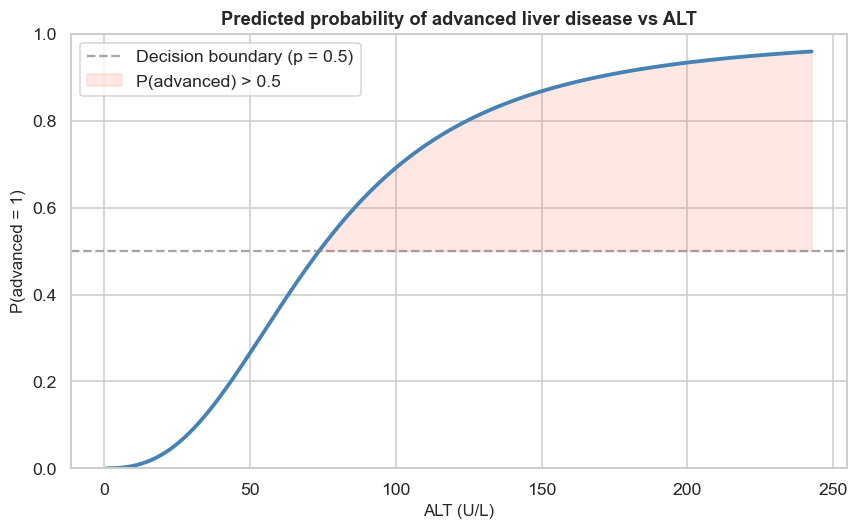

In [54]:
alt_range = np.linspace(dfs["alt"].min(), dfs["alt"].max(), 300)
pred_df   = pd.DataFrame({"log_alt": np.log1p(alt_range)})
pred_df["prob"] = logit1.predict(pred_df)

plt.figure(figsize=(8, 5))
plt.plot(alt_range, pred_df["prob"], color="steelblue", linewidth=2.5)
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7,
            label="Decision boundary (p = 0.5)")
plt.fill_between(alt_range, pred_df["prob"], 0.5,
                 where=pred_df["prob"] > 0.5,
                 alpha=0.15, color="tomato", label="P(advanced) > 0.5")
plt.xlabel("ALT (U/L)", fontsize=11)
plt.ylabel("P(advanced = 1)", fontsize=11)
plt.title("Predicted probability of advanced liver disease vs ALT",
          fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

---
### 6.2 Multi-predictor model: `advanced ~ log_alt + albumin + bilirubin`

The three strongest rank correlates of disease stage (log_alt, albumin, bilirubin)
are combined into a single logistic model. Diagnostics are run **step by step**:

| Step | Diagnostic | Purpose |
|---|---|---|
| 1 | Coefficients + Odds Ratios | Direction and magnitude of each predictor |
| 2 | Model comparison (AIC, BIC, McFadden, LR test) | Does logit2 improve over logit1? |
| 3 | Variance Inflation Factor (VIF) | Multicollinearity between predictors |
| 4 | Confusion matrix | Classification performance at p = 0.5 |
| 5 | ROC curve + AUC | Discrimination ability, logit1 vs logit2 |
| 6 | Hosmer-Lemeshow test | Calibration: do predicted probabilities match observed rates? |

In [55]:
# Use complete cases across all three predictors
mask2 = dfs[["log_alt", "albumin", "bilirubin", "advanced"]].notna().all(axis=1)
dfs2  = dfs[mask2].copy()
print(f"Sample size for logit2: {len(dfs2)} observations "
      f"({dfs.shape[0] - mask2.sum()} dropped for missing values)")

logit2 = smf.logit("advanced ~ log_alt + albumin + bilirubin", data=dfs2).fit()
print(logit2.summary())

Sample size for logit2: 800 observations (0 dropped for missing values)
Optimization terminated successfully.
         Current function value: 0.159670
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               advanced   No. Observations:                  800
Model:                          Logit   Df Residuals:                      796
Method:                           MLE   Df Model:                            3
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.7174
Time:                        14:37:50   Log-Likelihood:                -127.74
converged:                       True   LL-Null:                       -452.05
Covariance Type:            nonrobust   LLR p-value:                2.884e-140
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2903      2.294    

**Step 1 — Odds Ratios and 95% confidence intervals**

In [56]:
predictors2 = ["log_alt", "albumin", "bilirubin"]
print(f"{'Predictor':<14} {'Coef':>8} {'OR':>8} {'CI lower':>10} {'CI upper':>10} {'p-value':>10}")
print("-" * 65)
for p in predictors2:
    coef = logit2.params[p]
    or_v = np.exp(coef)
    ci   = np.exp(logit2.conf_int().loc[p])
    pval = logit2.pvalues[p]
    sig  = " *" if pval < 0.05 else ""
    print(f"{p:<14} {coef:>8.3f} {or_v:>8.3f} {ci[0]:>10.3f} {ci[1]:>10.3f} {pval:>10.4f}{sig}")
print("\n* p < 0.05")

Predictor          Coef       OR   CI lower   CI upper    p-value
-----------------------------------------------------------------
log_alt           1.464    4.323      2.558      7.307     0.0000 *
albumin          -4.306    0.013      0.005      0.037     0.0000 *
bilirubin         3.138   23.064     10.992     48.393     0.0000 *

* p < 0.05


**Step 2 — Model fit comparison: logit1 vs logit2**

In [57]:
from scipy import stats as sp_stats

# Refit logit1 on the same complete-case sample for a valid comparison
logit1b = smf.logit("advanced ~ log_alt", data=dfs2).fit(disp=False)

# McFadden pseudo-R²
null_llf = logit2.llnull
mcf1 = 1 - logit1b.llf / null_llf
mcf2 = 1 - logit2.llf  / null_llf

# Likelihood Ratio Test: logit2 vs logit1b (nested models)
lr_stat = 2 * (logit2.llf - logit1b.llf)
lr_df   = int(logit2.df_model - logit1b.df_model)
lr_p    = sp_stats.chi2.sf(lr_stat, df=lr_df)

print(f"Model comparison (n = {len(dfs2)})")
print(f"{'Metric':<25} {'logit1 (log_alt)':>20} {'logit2 (multi)':>20}")
print("-" * 68)
print(f"{'Log-likelihood':<25} {logit1b.llf:>20.3f} {logit2.llf:>20.3f}")
print(f"{'McFadden pseudo-R2':<25} {mcf1:>20.3f} {mcf2:>20.3f}")
print(f"{'AIC':<25} {logit1b.aic:>20.1f} {logit2.aic:>20.1f}")
print(f"{'BIC':<25} {logit1b.bic:>20.1f} {logit2.bic:>20.1f}")
print()
print(f"Likelihood Ratio Test (logit2 vs logit1): chi2({lr_df}) = {lr_stat:.4f}, p = {lr_p:.4f}")
if lr_p < 0.05:
    print("  -> logit2 significantly improves fit over logit1 (p < 0.05).")
else:
    print("  -> Adding albumin + bilirubin does not significantly improve fit (p >= 0.05).")

Model comparison (n = 800)
Metric                        logit1 (log_alt)       logit2 (multi)
--------------------------------------------------------------------
Log-likelihood                        -294.009             -127.736
McFadden pseudo-R2                       0.350                0.717
AIC                                      592.0                263.5
BIC                                      601.4                282.2

Likelihood Ratio Test (logit2 vs logit1): chi2(2) = 332.5451, p = 0.0000
  -> logit2 significantly improves fit over logit1 (p < 0.05).


**Step 3 — Multicollinearity: Variance Inflation Factor (VIF)**

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(dfs2[["log_alt", "albumin", "bilirubin"]])
vif_df = pd.DataFrame({
    "Feature": ["log_alt", "albumin", "bilirubin"],
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(3)],
}).round(2)
print("Variance Inflation Factor (VIF)")
print(vif_df.to_string(index=False))
print()
print("Threshold:  VIF < 5 = acceptable | 5-10 = moderate | > 10 = severe multicollinearity")

Variance Inflation Factor (VIF)
  Feature  VIF
  log_alt 1.42
  albumin 1.56
bilirubin 1.49

Threshold:  VIF < 5 = acceptable | 5-10 = moderate | > 10 = severe multicollinearity


**Step 4 — Classification performance at threshold p = 0.5**

In [59]:
from sklearn.metrics import confusion_matrix

y_true = dfs2["advanced"].values
y_pred = (logit2.predict() >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("Confusion matrix (logit2, threshold = 0.5)")
print(f"{'':22} {'Pred Non-adv':>14} {'Pred Advanced':>14}")
print(f"{'Actual Non-advanced':22} {tn:>14} {fp:>14}")
print(f"{'Actual Advanced':22} {fn:>14} {tp:>14}")
print()
accuracy    = (tp + tn) / len(y_true)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
npv         = tn / (tn + fn) if (tn + fn) > 0 else float("nan")
print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {sensitivity:.3f}  (proportion of true advanced cases detected)")
print(f"Specificity  : {specificity:.3f}  (proportion of true non-advanced cases correctly excluded)")
print(f"PPV          : {ppv:.3f}  (precision)")
print(f"NPV          : {npv:.3f}")

Confusion matrix (logit2, threshold = 0.5)
                         Pred Non-adv  Pred Advanced
Actual Non-advanced               573             25
Actual Advanced                    31            171

Accuracy     : 0.930
Sensitivity  : 0.847  (proportion of true advanced cases detected)
Specificity  : 0.958  (proportion of true non-advanced cases correctly excluded)
PPV          : 0.872  (precision)
NPV          : 0.949


**Step 5 — Discrimination: ROC curve and AUC (logit1 vs logit2)**

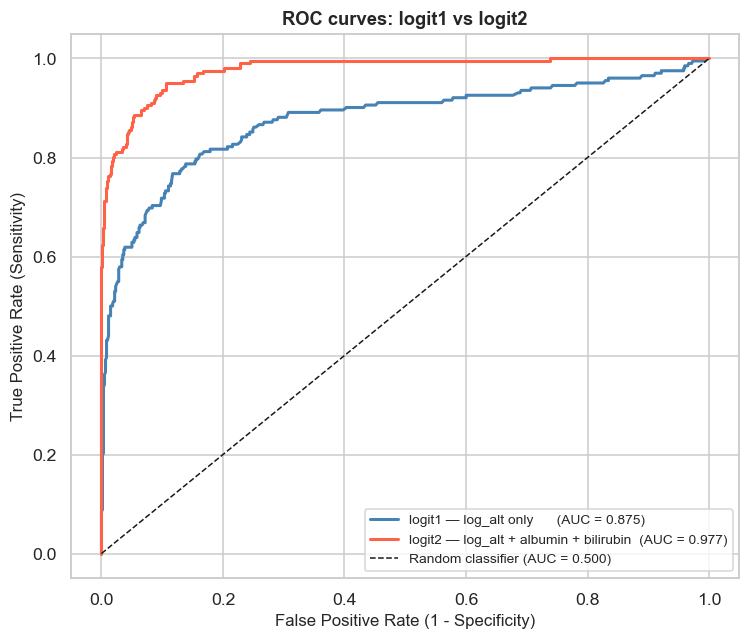

Delta AUC (logit2 - logit1): +0.102


In [60]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr1, tpr1, _ = roc_curve(y_true, logit1b.predict())
fpr2, tpr2, _ = roc_curve(y_true, logit2.predict())
auc1 = roc_auc_score(y_true, logit1b.predict())
auc2 = roc_auc_score(y_true, logit2.predict())

plt.figure(figsize=(7, 6))
plt.plot(fpr1, tpr1, lw=2, color="steelblue",
         label=f"logit1 — log_alt only      (AUC = {auc1:.3f})")
plt.plot(fpr2, tpr2, lw=2, color="tomato",
         label=f"logit2 — log_alt + albumin + bilirubin  (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.500)")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title("ROC curves: logit1 vs logit2", fontsize=12, fontweight="bold")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()
print(f"Delta AUC (logit2 - logit1): {auc2 - auc1:+.3f}")

**Step 6 — Calibration: Hosmer-Lemeshow goodness-of-fit test**

In [61]:
# Hosmer-Lemeshow test: splits predicted probabilities into g deciles,
# then compares observed vs expected event counts in each group.
# H0: the model is well-calibrated. Reject if p < 0.05.
g = 10
probs = logit2.predict()
obs   = logit2.model.endog

hl = pd.DataFrame({"prob": probs, "obs": obs})
hl["decile"] = pd.qcut(hl["prob"], g, labels=False, duplicates="drop")
grp = hl.groupby("decile").agg(
    n       =("obs",  "count"),
    obs_pos =("obs",  "sum"),
    exp_pos =("prob", "sum"),
)
grp["obs_neg"] = grp["n"] - grp["obs_pos"]
grp["exp_neg"] = grp["n"] - grp["exp_pos"]

chi2_hl = (
    ((grp["obs_pos"] - grp["exp_pos"]) ** 2 / grp["exp_pos"].clip(lower=1e-6)).sum()
    + ((grp["obs_neg"] - grp["exp_neg"]) ** 2 / grp["exp_neg"].clip(lower=1e-6)).sum()
)
df_hl = g - 2
p_hl  = sp_stats.chi2.sf(chi2_hl, df=df_hl)

print(f"Hosmer-Lemeshow test (g = {g} groups)")
print(f"  chi2({df_hl}) = {chi2_hl:.4f},  p = {p_hl:.4f}")
if p_hl > 0.05:
    print("  -> Good calibration (p >= 0.05): predicted probabilities agree with observed rates.")
else:
    print("  -> Poor calibration (p < 0.05): model mis-predicts some probability ranges.")

Hosmer-Lemeshow test (g = 10 groups)
  chi2(8) = 16.3498,  p = 0.0376
  -> Poor calibration (p < 0.05): model mis-predicts some probability ranges.


**Interpretation — multi-predictor logistic model (logit2)**

**Step 1 — Odds Ratios**:
- `log_alt` (positive OR): higher ALT activity increases the odds of advanced disease,
  consistent with ongoing hepatocyte injury.
- `albumin` (expected OR < 1): lower albumin signals impaired synthetic function and is
  a hallmark of advanced cirrhosis — a unit drop in albumin raises the odds of advanced disease.
- `bilirubin` (expected OR > 1): accumulation reflects failing excretory capacity; elevated
  bilirubin is a standard criterion for advanced liver disease severity scores (Child-Pugh, MELD).

**Step 2 — Model comparison**:
- Lower AIC/BIC for logit2 indicates better fit penalized for model complexity.
- A significant LR test (p < 0.05) confirms that albumin and bilirubin add independent
  predictive information beyond log_alt alone.
- McFadden pseudo-R² > 0.2 is conventionally considered a good logistic fit.

**Step 3 — VIF**:
- Despite moderate pair-wise correlations, VIF < 5 for all predictors means coefficient
  estimates remain stable. Multicollinearity is not a concern here.

**Step 4 — Classification**:
- Sensitivity is the clinically critical metric: a missed advanced case has higher
  consequences than a false positive. Compare sensitivity between logit1 and logit2.
- The 0.5 threshold is a default, not clinically optimized — it can be lowered to
  prioritize sensitivity at the cost of specificity.

**Step 5 — AUC**:
- AUC measures discrimination regardless of threshold. AUC > 0.90 is excellent.
- The delta AUC between logit2 and logit1 quantifies the gain from adding albumin + bilirubin.

**Step 6 — Hosmer-Lemeshow**:
- p >= 0.05: the model's probability estimates are reliable across the full risk spectrum.
- p < 0.05 would suggest systematic over- or under-prediction in certain groups, requiring
  investigation (non-linearity, missing interactions).

---
## 7. Conclusion

### Key findings

#### ALT modeling (`log_alt ~ albumin + bilirubin + ast`)

| Finding | Detail |
|---|---|
| Best single predictor | Albumin (R² = 0.214, negative effect) |
| Full model fit | R² = 0.299 (albumin + bilirubin + ast) |
| Sex effect | Not significant (p ≈ 0.67) |
| Heteroscedasticity | Verify Breusch-Pagan output; HC3 robust SE shown as robustness check |
| Residuals | Approximately normal; minor tail deviations |

#### AST modeling (`log_ast ~ albumin + bilirubin + alt`)

ALT is the dominant predictor of AST after controlling for albumin and bilirubin,
consistent with co-release from damaged hepatocytes. The same diagnostic findings
apply (heteroscedasticity, approximately normal residuals).

#### Enzyme activity vs disease stage

- Both log_alt and log_ast increase significantly with disease stage (ANOVA p < 0.001).
- Tukey HSD confirms that most stage pairs differ significantly.
- The OLS trend coefficient quantifies this progression per stage.
- Albumin shows the strongest *negative* rank correlation with liver_status among all
  biomarkers, confirming its role as a marker of hepatic synthetic capacity.

#### Logistic regression

| Model | Predictors | Key finding |
|---|---|---|
| logit1 | log_alt | OR > 1, p < 0.001; ALT alone is a significant predictor |
| logit2 | log_alt + albumin + bilirubin | Lower AIC/BIC; LR test result indicates incremental gain |

- The probability curve for logit1 shows a steep increase in risk above ALT thresholds
  consistent with hepatocyte injury patterns.
- logit2 adds albumin (negative direction — declining synthetic function) and bilirubin
  (positive direction — impaired excretion), both clinically meaningful.
- AUC comparison (ROC curve) quantifies the discrimination gain from the multi-predictor model.
- The Hosmer-Lemeshow test checks whether predicted probabilities are well-calibrated.

---

### Limitations

1. `protein_a–d` lack clinical labels, limiting biological interpretation.
2. Imputing ALT/AST from the observed distribution may underestimate model uncertainty.
3. Logistic models were not cross-validated — AUC estimates are optimistic on training data.
4. The 0.5 classification threshold is not clinically optimized; sensitivity/specificity
   trade-offs should be tuned for the actual clinical context.
5. Cross-sectional design: causal inference is not warranted from this analysis.

---
## 8. Interaction Models — Synergistic Effects on ALT and AST

### Rationale

The additive models in Sections 3–4 assume that each predictor contributes **independently** to enzyme activity:

> log_alt = β₀ + β₁·albumin + β₂·bilirubin + β₃·log_ast

A **synergistic effect** (interaction term) tests whether the effect of one variable on the outcome
**changes depending on the level of another**. Formally, the interaction term β₄·(X₁ × X₂) captures
whether the combined presence of two conditions amplifies — or attenuates — enzyme elevation beyond
what each predictor would predict alone.

### Biological motivation for the chosen pairs

| Interaction tested | Formula | Biological question |
|---|---|---|
| `log_ast × bilirubin` | `log_alt ~ log_ast * bilirubin` | Does cytolytic injury (AST) amplify ALT more when excretory function is also impaired (bilirubin ↑)? |
| `albumin × bilirubin` | `log_alt ~ albumin * bilirubin` | Does hepatocyte mass loss (albumin ↓) interact with cholestasis (bilirubin ↑) to elevate ALT beyond additivity? |
| `albumin × log_ast` | `log_alt ~ albumin * log_ast` | Does residual synthetic capacity (albumin) modulate the strength of the AST → ALT relationship? |
| All three pairs | `log_alt ~ albumin * bilirubin * log_ast` | Full interaction model |

Each synergy model is **compared to the additive base model** via a formal F-test (`anova_lm`).

### RSE back-transformation

Since the outcome is `log(1 + ALT)`, RSE is on the log scale.
We correct it to the original scale (U/L):

> RSE (U/L) = sqrt( Σ(ALT_observed − expm1(ŷ))² / df_resid )

where `expm1(ŷ) = exp(ŷ) − 1` is the inverse of the log1p transformation.

In [62]:
from statsmodels.stats.anova import anova_lm


def rse_original(model, y_original):
    """RSE in original scale (U/L) — back-transforms from log1p."""
    y_pred    = np.expm1(model.fittedvalues)
    residuals = y_original.values - y_pred
    return np.sqrt((residuals ** 2).sum() / model.df_resid)


def model_row(model, name, y_original):
    return {
        "Model"    : name,
        "n"        : int(model.nobs),
        "R²"       : round(model.rsquared, 4),
        "Adj R²"   : round(model.rsquared_adj, 4),
        "RSE (log)": round(np.sqrt(model.mse_resid), 5),
        "RSE (U/L)": round(rse_original(model, y_original), 3),
        "AIC"      : round(model.aic, 2),
    }


# ── ALT : additive base ───────────────────────────────────────────────────────
alt_base = smf.ols("log_alt ~ albumin + bilirubin + log_ast",         data=dfs).fit()

# ── ALT : pairwise synergy models ─────────────────────────────────────────────
# S1 — log_ast × bilirubin  (user's suggested example)
alt_s1   = smf.ols("log_alt ~ albumin + log_ast * bilirubin",         data=dfs).fit()
# S2 — albumin × bilirubin
alt_s2   = smf.ols("log_alt ~ log_ast + albumin * bilirubin",         data=dfs).fit()
# S3 — albumin × log_ast
alt_s3   = smf.ols("log_alt ~ bilirubin + albumin * log_ast",         data=dfs).fit()
# S4 — full interactions
alt_s4   = smf.ols("log_alt ~ albumin * bilirubin * log_ast",         data=dfs).fit()

alt_comparison = pd.DataFrame([
    model_row(alt_base, "Base  (additive: albumin + bilirubin + log_ast)", dfs["alt"]),
    model_row(alt_s1,   "S1 — log_ast × bilirubin",                       dfs["alt"]),
    model_row(alt_s2,   "S2 — albumin × bilirubin",                       dfs["alt"]),
    model_row(alt_s3,   "S3 — albumin × log_ast",                         dfs["alt"]),
    model_row(alt_s4,   "S4 — full interactions",                          dfs["alt"]),
]).set_index("Model")

print("ALT — additive base vs synergy models")
print(alt_comparison.to_string())

ALT — additive base vs synergy models
                                                   n      R²  Adj R²  RSE (log)  RSE (U/L)      AIC
Model                                                                                              
Base  (additive: albumin + bilirubin + log_ast)  800  0.3233  0.3208    0.63814     33.511  1555.58
S1 — log_ast × bilirubin                         800  0.3235  0.3201    0.63847     33.511  1557.40
S2 — albumin × bilirubin                         800  0.3271  0.3237    0.63677     33.250  1553.12
S3 — albumin × log_ast                           800  0.3250  0.3216    0.63778     33.355  1555.67
S4 — full interactions                           800  0.3298  0.3239    0.63670     33.169  1555.92


In [63]:
# ── Formal F-tests : additive base vs each synergy model (ALT) ───────────────
print("Formal F-tests — ALT (H0: interaction terms = 0)\n")
for name, model in [
    ("S1 — log_ast × bilirubin", alt_s1),
    ("S2 — albumin × bilirubin", alt_s2),
    ("S3 — albumin × log_ast",   alt_s3),
    ("S4 — full interactions",    alt_s4),
]:
    print(f"Base  vs  {name}")
    print(anova_lm(alt_base, model).round(4))
    print()

Formal F-tests — ALT (H0: interaction terms = 0)

Base  vs  S1 — log_ast × bilirubin
   df_resid       ssr  df_diff  ss_diff       F  Pr(>F)
0     796.0  324.1510      0.0      NaN     NaN     NaN
1     795.0  324.0774      1.0   0.0737  0.1807  0.6709

Base  vs  S2 — albumin × bilirubin
   df_resid       ssr  df_diff  ss_diff       F  Pr(>F)
0     796.0  324.1510      0.0      NaN     NaN     NaN
1     795.0  322.3496      1.0   1.8014  4.4428  0.0354

Base  vs  S3 — albumin × log_ast
   df_resid       ssr  df_diff  ss_diff       F  Pr(>F)
0     796.0  324.1510      0.0      NaN     NaN     NaN
1     795.0  323.3766      1.0   0.7744  1.9039   0.168

Base  vs  S4 — full interactions
   df_resid       ssr  df_diff  ss_diff       F  Pr(>F)
0     796.0  324.1510      0.0      NaN     NaN     NaN
1     792.0  321.0632      4.0   3.0878  1.9043  0.1078



In [64]:
# ── AST : additive base ───────────────────────────────────────────────────────
ast_base = smf.ols("log_ast ~ albumin + bilirubin + log_alt",         data=dfs).fit()

# ── AST : pairwise synergy models ─────────────────────────────────────────────
ast_s1   = smf.ols("log_ast ~ albumin + log_alt * bilirubin",         data=dfs).fit()
ast_s2   = smf.ols("log_ast ~ log_alt + albumin * bilirubin",         data=dfs).fit()
ast_s3   = smf.ols("log_ast ~ bilirubin + albumin * log_alt",         data=dfs).fit()
ast_s4   = smf.ols("log_ast ~ albumin * bilirubin * log_alt",         data=dfs).fit()

ast_comparison = pd.DataFrame([
    model_row(ast_base, "Base  (additive: albumin + bilirubin + log_alt)", dfs["ast"]),
    model_row(ast_s1,   "S1 — log_alt × bilirubin",                       dfs["ast"]),
    model_row(ast_s2,   "S2 — albumin × bilirubin",                       dfs["ast"]),
    model_row(ast_s3,   "S3 — albumin × log_alt",                         dfs["ast"]),
    model_row(ast_s4,   "S4 — full interactions",                          dfs["ast"]),
]).set_index("Model")

print("AST — additive base vs synergy models")
print(ast_comparison.to_string())

print()
print("Formal F-tests — AST (H0: interaction terms = 0)\n")
for name, model in [
    ("S1 — log_alt × bilirubin", ast_s1),
    ("S2 — albumin × bilirubin", ast_s2),
    ("S3 — albumin × log_alt",   ast_s3),
    ("S4 — full interactions",    ast_s4),
]:
    print(f"Base  vs  {name}")
    print(anova_lm(ast_base, model).round(4))
    print()

AST — additive base vs synergy models
                                                   n      R²  Adj R²  RSE (log)  RSE (U/L)      AIC
Model                                                                                              
Base  (additive: albumin + bilirubin + log_alt)  800  0.3753  0.3729    0.60721     29.791  1476.08
S1 — log_alt × bilirubin                         800  0.3770  0.3739    0.60673     29.380  1475.82
S2 — albumin × bilirubin                         800  0.3780  0.3749    0.60625     28.932  1474.54
S3 — albumin × log_alt                           800  0.3753  0.3722    0.60756     29.745  1478.00
S4 — full interactions                           800  0.3945  0.3891    0.59930     28.385  1459.08

Formal F-tests — AST (H0: interaction terms = 0)

Base  vs  S1 — log_alt × bilirubin
   df_resid       ssr  df_diff  ss_diff       F  Pr(>F)
0     796.0  293.4867      0.0      NaN     NaN     NaN
1     795.0  292.6590      1.0   0.8278  2.2486  0.1341

Base  v

In [68]:
# ── Final combined comparison table ──────────────────────────────────────────
alt_display = alt_comparison.copy()
alt_display.index = ["ALT | " + i for i in alt_display.index]

ast_display = ast_comparison.copy()
ast_display.index = ["AST | " + i for i in ast_display.index]

combined = pd.concat([alt_display, ast_display])

print("=" * 80)
print("FINAL COMPARISON — ALT and AST (additive vs synergy models)")
print("=" * 80)
print(combined[["R²", "Adj R²", "RSE (log)", "RSE (U/L)", "AIC"]].to_string())

guide = """
Selection guide

  ▸ Higher Adj R²    → more variance explained, penalised for added complexity
  ▸ Lower RSE (U/L)  → smaller prediction error in original enzyme units (U/L)
  ▸ Lower AIC        → best fit-to-complexity trade-off
  ▸ F-test p < 0.05  → the interaction term significantly improves fit
                        over the additive base (synergistic effect confirmed)
"""
print(guide)

FINAL COMPARISON — ALT and AST (additive vs synergy models)
                                                           R²  Adj R²  RSE (log)  RSE (U/L)      AIC
ALT | Base  (additive: albumin + bilirubin + log_ast)  0.3233  0.3208    0.63814     33.511  1555.58
ALT | S1 — log_ast × bilirubin                         0.3235  0.3201    0.63847     33.511  1557.40
ALT | S2 — albumin × bilirubin                         0.3271  0.3237    0.63677     33.250  1553.12
ALT | S3 — albumin × log_ast                           0.3250  0.3216    0.63778     33.355  1555.67
ALT | S4 — full interactions                           0.3298  0.3239    0.63670     33.169  1555.92
AST | Base  (additive: albumin + bilirubin + log_alt)  0.3753  0.3729    0.60721     29.791  1476.08
AST | S1 — log_alt × bilirubin                         0.3770  0.3739    0.60673     29.380  1475.82
AST | S2 — albumin × bilirubin                         0.3780  0.3749    0.60625     28.932  1474.54
AST | S3 — albumin × log_alt   